In [4]:
import os
import numpy as np
import pandas as pd
import sys
import json
import glob
import math
import random
import pickle
from collections import Counter, defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from IPython.display import display


plt.style.use("default")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [6]:
# Colab setup
!nvidia-smi
!python --version

Mon Mar 16 14:16:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!pip install -q trimesh open3d pyvista tqdm easydict tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.5/740.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 98.2 MB/s eta 0:00:00


In [8]:
import trimesh

In [ ]:
!git clone https://github.com/jw9730/setvae.git
%cd setvae

Cloning into 'setvae'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 129 (delta 27), reused 23 (delta 23), pack-reused 82 (from 1)
Receiving objects: 100% (129/129), 4.71 MiB | 3.00 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/setvae


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/teeth_setvae
!mkdir -p /content/drive/MyDrive/teeth_setvae/data
!mkdir -p /content/drive/MyDrive/teeth_setvae/processed
!mkdir -p /content/drive/MyDrive/teeth_setvae/processed

In [ ]:
root = "/content/drive/MyDrive/teeth_setvae/data"
files = sorted(os.listdir(root))
print(files)

[]


In [ ]:
zip_root = "/content/drive/MyDrive/teeth_setvae/data"
extract_root = "/content/drive/MyDrive/teeth_setvae/raw_dataset"
os.makedirs(extract_root, exist_ok=True)

print("zip_root:", zip_root)
print("extract_root:", extract_root)

zip_root: /content/drive/MyDrive/teeth_setvae/data
extract_root: /content/drive/MyDrive/teeth_setvae/raw_dataset


# **Extracting and organizing the raw dental dataset**

In [ ]:
from tqdm import tqdm
import zipfile
import os

zip_root = "/content/drive/MyDrive/teeth_setvae/data"
extract_root = "/content/drive/MyDrive/teeth_setvae/raw_dataset"

os.makedirs(extract_root, exist_ok=True)

zip_files = sorted([
    os.path.join(zip_root, f)
    for f in os.listdir(zip_root)
    if f.lower().endswith(".zip")
])

print("Found", len(zip_files), "zip files")

for zf in tqdm(zip_files):
    with zipfile.ZipFile(zf, "r") as zip_ref:
        zip_ref.extractall(extract_root)

    os.remove(zf)

Found 7 zip files


100%|██████████| 7/7 [16:37<00:00, 142.45s/it]


In [ ]:
import os
from collections import Counter

RAW_ROOT = "/content/drive/MyDrive/teeth_setvae/raw_dataset"

pairs = []
obj_only = []
json_only = []

for jaw in ["lower", "upper"]:
    jaw_dir = os.path.join(RAW_ROOT, jaw)
    if not os.path.exists(jaw_dir):
        continue

    for patient_id in sorted(os.listdir(jaw_dir)):
        patient_dir = os.path.join(jaw_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue

        obj_path = os.path.join(patient_dir, f"{patient_id}_{jaw}.obj")
        json_path = os.path.join(patient_dir, f"{patient_id}_{jaw}.json")

        has_obj = os.path.exists(obj_path)
        has_json = os.path.exists(json_path)

        if has_obj and has_json:
            pairs.append((patient_id, jaw, obj_path, json_path))
        elif has_obj and not has_json:
            obj_only.append((patient_id, jaw, obj_path))
        elif has_json and not has_obj:
            json_only.append((patient_id, jaw, json_path))

print("Valid pairs:", len(pairs))
print("OBJ only:", len(obj_only))
print("JSON only:", len(json_only))

print("\nFirst 10 OBJ only:")
for x in obj_only[:10]:
    print(x)

print("\nFirst 10 JSON only:")
for x in json_only[:10]:
    print(x)

Valid pairs: 1800
OBJ only: 100
JSON only: 0

First 10 OBJ only:
('01WU1B7C', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/01WU1B7C/01WU1B7C_lower.obj')
('13GRE9RZ', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/13GRE9RZ/13GRE9RZ_lower.obj')
('1AJFNIDV', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/1AJFNIDV/1AJFNIDV_lower.obj')
('233LFZAG', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/233LFZAG/233LFZAG_lower.obj')
('3IAO5RVQ', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/3IAO5RVQ/3IAO5RVQ_lower.obj')
('3JIYO434', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/3JIYO434/3JIYO434_lower.obj')
('3PBLPI5H', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/3PBLPI5H/3PBLPI5H_lower.obj')
('3TROMS4N', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/3TROMS4N/3TROMS4N_lower.obj')
('5OL9XCLF', 'lower', '/content/drive/MyDrive/teeth_setvae/raw_dataset/lower/5O

# **Verifying dataset integrity**

In [ ]:
patient_id, jaw, obj_path, json_path = pairs[0]
print("Patient:", patient_id)
print("Jaw:", jaw)
print("OBJ:", obj_path)
print("JSON:", json_path)

mesh = trimesh.load(obj_path, process=False)
vertices = np.asarray(mesh.vertices)
faces = np.asarray(mesh.faces) if hasattr(mesh, "faces") else None

print("Vertices shape:", vertices.shape)
print("Faces shape:", None if faces is None else faces.shape)

with open(json_path, "r") as f:
    ann = json.load(f)

print("JSON keys:", ann.keys())
for k, v in ann.items():
    if isinstance(v, list):
        print(k, "length =", len(v))
    else:
        print(k, type(v), v)

Patient: 00OMSZGW
Jaw: lower
OBJ: /content/drive/MyDrive/teeth_setvae/raw_dataset/lower/00OMSZGW/00OMSZGW_lower.obj
JSON: /content/drive/MyDrive/teeth_setvae/raw_dataset/lower/00OMSZGW/00OMSZGW_lower.json
Vertices shape: (180225, 3)
Faces shape: (359917, 3)
JSON keys: dict_keys(['id_patient', 'jaw', 'labels', 'instances'])
id_patient <class 'str'> 00OMSZGW
jaw <class 'str'> lower
labels length = 180225
instances length = 180225


In [ ]:
bad_samples = []
good_samples = 0

for patient_id, jaw, obj_path, json_path in tqdm(pairs):
    try:
        mesh = trimesh.load(obj_path, process=False)
        vertices = np.asarray(mesh.vertices)

        with open(json_path, "r") as f:
            ann = json.load(f)

        labels = ann.get("labels", None)
        instances = ann.get("instances", None)

        if vertices.ndim != 2 or vertices.shape[1] != 3:
            bad_samples.append((patient_id, jaw, "bad_vertices_shape", vertices.shape))
            continue

        if labels is None:
            bad_samples.append((patient_id, jaw, "missing_labels"))
            continue

        if instances is None:
            bad_samples.append((patient_id, jaw, "missing_instances"))
            continue

        if len(labels) != len(vertices):
            bad_samples.append((patient_id, jaw, "labels_length_mismatch", len(labels), len(vertices)))
            continue

        if len(instances) != len(vertices):
            bad_samples.append((patient_id, jaw, "instances_length_mismatch", len(instances), len(vertices)))
            continue

        good_samples += 1

    except Exception as e:
        bad_samples.append((patient_id, jaw, "exception", str(e)))

print("Good samples:", good_samples)
print("Bad samples:", len(bad_samples))
print("\nFirst 20 bad samples:")
for x in bad_samples[:20]:
    print(x)

100%|██████████| 1800/1800 [50:44<00:00,  1.69s/it]

Good samples: 1800
Bad samples: 0

First 20 bad samples:


# **Preprocessing full-jaw meshes into point clouds**

In [ ]:
RAW_ROOT = "/content/drive/MyDrive/teeth_setvae/raw_dataset"
OUT_ROOT = "/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048"
os.makedirs(OUT_ROOT, exist_ok=True)

N_POINTS = 2048
SEED = 42
rng = np.random.default_rng(SEED)

def normalize_points(points):
    points = points.astype(np.float32)
    center = points.mean(axis=0, keepdims=True)
    points = points - center
    scale = np.linalg.norm(points, axis=1).max()
    if scale > 0:
        points = points / scale
    return points, center.astype(np.float32), np.float32(scale)

def sample_indices(n_vertices, n_points=2048):
    if n_vertices >= n_points:
        idx = rng.choice(n_vertices, size=n_points, replace=False)
    else:
        idx = rng.choice(n_vertices, size=n_points, replace=True)
    return idx

saved = 0
failed = []

for patient_id, jaw, obj_path, json_path in tqdm(pairs):
    try:
        mesh = trimesh.load(obj_path, process=False)
        vertices = np.asarray(mesh.vertices, dtype=np.float32)

        with open(json_path, "r") as f:
            ann = json.load(f)

        labels = np.asarray(ann["labels"], dtype=np.int32)
        instances = np.asarray(ann["instances"], dtype=np.int32)

        idx = sample_indices(len(vertices), N_POINTS)

        points_sampled = vertices[idx]
        labels_sampled = labels[idx]
        instances_sampled = instances[idx]

        points_norm, center, scale = normalize_points(points_sampled)

        out_path = os.path.join(OUT_ROOT, f"{patient_id}_{jaw}.npz")
        np.savez_compressed(
            out_path,
            points=points_norm.astype(np.float32),            # [2048, 3]
            labels=labels_sampled.astype(np.int32),           # [2048]
            instances=instances_sampled.astype(np.int32),     # [2048]
            jaw=np.array(jaw),
            patient_id=np.array(patient_id),
            center=center,
            scale=np.array(scale, dtype=np.float32),
            original_num_vertices=np.array(len(vertices), dtype=np.int32),
        )
        saved += 1

    except Exception as e:
        failed.append((patient_id, jaw, str(e)))

print("Saved:", saved)
print("Failed:", len(failed))
print("First 10 failed:", failed[:10])

100%|██████████| 1800/1800 [56:47<00:00,  1.89s/it]

Saved: 1800
Failed: 0
First 10 failed: []


In [ ]:
processed_files = sorted(glob.glob("/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/*.npz"))
print("Processed files:", len(processed_files))
print("First 5:", processed_files[:5])

sample = np.load(processed_files[0], allow_pickle=True)
print("\nKeys:", sample.files)
print("points:", sample["points"].shape, sample["points"].dtype)
print("labels:", sample["labels"].shape, sample["labels"].dtype)
print("instances:", sample["instances"].shape, sample["instances"].dtype)
print("jaw:", sample["jaw"])
print("patient_id:", sample["patient_id"])
print("original_num_vertices:", sample["original_num_vertices"])

Processed files: 1800
First 5: ['/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/00OMSZGW_lower.npz', '/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/00OMSZGW_upper.npz', '/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/01328DDN_lower.npz', '/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/01328DDN_upper.npz', '/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048/0132CR0A_lower.npz']

Keys: ['points', 'labels', 'instances', 'jaw', 'patient_id', 'center', 'scale', 'original_num_vertices']
points: (2048, 3) float32
labels: (2048,) int32
instances: (2048,) int32
jaw: lower
patient_id: 00OMSZGW
original_num_vertices: 180225


In [ ]:
processed_root = "/content/drive/MyDrive/teeth_setvae/processed_fulljaw_2048"
split_root = "/content/drive/MyDrive/teeth_setvae/splits"
os.makedirs(split_root, exist_ok=True)

files = sorted(glob.glob(os.path.join(processed_root, "*.npz")))
random.seed(42)
random.shuffle(files)

n_train = int(0.9 * len(files))
train_files = files[:n_train]
val_files = files[n_train:]

with open(os.path.join(split_root, "train.txt"), "w") as f:
    f.write("\n".join(train_files))

with open(os.path.join(split_root, "val.txt"), "w") as f:
    f.write("\n".join(val_files))

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 1620
Val: 180


# **SetVAE**

In [ ]:
%cd /content/setvae
!sed -n '1,260p' datasets/ShapeNet.py

/content/setvae
"""
Set-MultiMNIST dataset
Mostly copy-and-paste from https://github.com/stevenygd/PointFlow
"""
import os
import random
import numpy as np

import torch
import torch.utils.data

# taken from https://github.com/optas/latent_3d_points/blob/8e8f29f8124ed5fc59439e8551ba7ef7567c9a37/src/in_out.py
synsetid_to_cate = {
    '02691156': 'airplane', '02773838': 'bag', '02801938': 'basket',
    '02808440': 'bathtub', '02818832': 'bed', '02828884': 'bench',
    '02876657': 'bottle', '02880940': 'bowl', '02924116': 'bus',
    '02933112': 'cabinet', '02747177': 'can', '02942699': 'camera',
    '02954340': 'cap', '02958343': 'car', '03001627': 'chair',
    '03046257': 'clock', '03207941': 'dishwasher', '03211117': 'monitor',
    '04379243': 'table', '04401088': 'telephone', '02946921': 'tin_can',
    '04460130': 'tower', '04468005': 'train', '03085013': 'keyboard',
    '03261776': 'earphone', '03325088': 'faucet', '03337140': 'file',
    '03467517': 'guitar', '03513137': 'helmet', '0

# **Create datasets/Teeth3DS.py**

In [ ]:
%%writefile /content/setvae/datasets/Teeth3DS.py


def init_np_seed(worker_id):
    seed = torch.initial_seed()
    np.random.seed(seed % 4294967296)


class TeethPointClouds(torch.utils.data.Dataset):
    def __init__(
        self,
        split_file,
        split='train',
        tr_sample_size=2048,
        te_sample_size=2048,
        random_subsample=False,
        standardize_per_shape=False,
        random_offset=False,
        input_dim=3
    ):
        self.split = split
        assert self.split in ['train', 'val', 'test']

        self.split_file = split_file
        self.random_subsample = random_subsample
        self.standardize_per_shape = standardize_per_shape
        self.random_offset = random_offset
        self.input_dim = input_dim

        with open(split_file, "r") as f:
            self.files = [line.strip() for line in f if line.strip()]

        self.all_points = []
        self.labels_meta = []
        self.instances_meta = []
        self.jaw_meta = []
        self.patient_meta = []
        self.sample_ids = []

        for path in self.files:
            data = np.load(path, allow_pickle=True)
            pts = data["points"].astype(np.float32)   # [2048, 3]
            self.all_points.append(pts[np.newaxis, ...])

            self.labels_meta.append(data["labels"].astype(np.int64))
            self.instances_meta.append(data["instances"].astype(np.int64))
            self.jaw_meta.append(str(data["jaw"]))
            self.patient_meta.append(str(data["patient_id"]))
            self.sample_ids.append(os.path.basename(path).replace(".npz", ""))

        self.all_points = np.concatenate(self.all_points, axis=0)  # [N, 2048, 3]

        # dataset-level normalization stats (to match ShapeNet style)
        self.all_points_mean = self.all_points.reshape(-1, input_dim).mean(axis=0).reshape(1, 1, input_dim)
        self.all_points_std = self.all_points.reshape(-1).std(axis=0).reshape(1, 1, 1)

        self.all_points = (self.all_points - self.all_points_mean) / self.all_points_std

        self.tr_sample_size = min(self.all_points.shape[1], tr_sample_size)
        self.te_sample_size = min(self.all_points.shape[1], te_sample_size)

        print(f"[{self.split}] Total number of data: {len(self.all_points)}")
        print(f"[{self.split}] Point count per sample: {self.all_points.shape[1]}")
        print(f"[{self.split}] tr_sample_size={self.tr_sample_size}, te_sample_size={self.te_sample_size}")

    def __len__(self):
        return len(self.all_points)

    def get_pc_stats(self, idx):
        return self.all_points_mean.reshape(1, -1), self.all_points_std.reshape(1, -1)

    def save_statistics(self, save_dir):
        np.save(os.path.join(save_dir, f"{self.split}_set_mean.npy"), self.all_points_mean)
        np.save(os.path.join(save_dir, f"{self.split}_set_std.npy"), self.all_points_std)
        np.save(os.path.join(save_dir, f"{self.split}_set_idx.npy"), np.arange(len(self.all_points)))

    def __getitem__(self, idx):
        pts = self.all_points[idx]  # [2048, 3]

        if self.split == 'train':
            sample_size = self.tr_sample_size
        else:
            sample_size = self.te_sample_size

        if self.random_subsample:
            choice = np.random.choice(pts.shape[0], sample_size, replace=False)
        else:
            choice = np.arange(sample_size)

        out = torch.from_numpy(pts[choice, :]).float()

        ofs = out.mean(0, keepdim=True)

        if self.standardize_per_shape:
            out = out - ofs

        if self.random_offset:
            if random.uniform(0., 1.) < 0.2:
                scale = random.uniform(1., 1.5)
                out = out - ofs
                ofs = ofs * scale
                out = out + ofs

        m, s = self.get_pc_stats(idx)
        m = torch.from_numpy(np.asarray(m))
        s = torch.from_numpy(np.asarray(s))

        sid = self.jaw_meta[idx]   # ShapeNet-style category slot
        mid = self.sample_ids[idx] # sample id
        label = 0                  # single-category dataset for now

        return {
            'idx': idx,
            'set': out,
            'offset': ofs,
            'mean': m,
            'std': s,
            'label': label,
            'sid': sid,
            'mid': mid,
            # extras for later analysis
            'jaw': self.jaw_meta[idx],
            'patient_id': self.patient_meta[idx],
            'vertex_labels': torch.from_numpy(self.labels_meta[idx][choice]).long(),
            'vertex_instances': torch.from_numpy(self.instances_meta[idx][choice]).long(),
        }


def collate_fn(batch):
    ret = dict()
    for k, v in batch[0].items():
        ret[k] = [b[k] for b in batch]

    mean = torch.stack(ret['mean'], dim=0)       # [B, 1, 3]
    std = torch.stack(ret['std'], dim=0)         # [B, 1, 1]
    s = torch.stack(ret['set'], dim=0)           # [B, N, 3]
    offset = torch.stack(ret['offset'], dim=0)   # [B, 1, 3]
    mask = torch.zeros(s.size(0), s.size(1)).bool()
    cardinality = torch.ones(s.size(0), dtype=torch.long) * s.size(1)
    label = torch.tensor(ret['label'], dtype=torch.long)

    return {
        'idx': ret['idx'],
        'set': s,
        'offset': offset,
        'mean': mean,
        'std': std,
        'mask': mask,
        'cardinality': cardinality,
        'label': label,
        'sid': ret['sid'],
        'mid': ret['mid'],
        # extras
        'jaw': ret['jaw'],
        'patient_id': ret['patient_id'],
        'vertex_labels': torch.stack(ret['vertex_labels'], dim=0),
        'vertex_instances': torch.stack(ret['vertex_instances'], dim=0),
    }


def build(args):
    train_dataset = TeethPointClouds(
        split_file=args.teeth_train_split,
        split='train',
        tr_sample_size=args.tr_max_sample_points,
        te_sample_size=args.te_max_sample_points,
        random_subsample=args.random_subsample,
        standardize_per_shape=args.standardize_per_shape,
        random_offset=args.random_offset,
    )

    val_dataset = TeethPointClouds(
        split_file=args.teeth_val_split,
        split='val',
        tr_sample_size=args.tr_max_sample_points,
        te_sample_size=args.te_max_sample_points,
        random_subsample=False,
        standardize_per_shape=args.standardize_per_shape,
        random_offset=False,
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        pin_memory=True,
        drop_last=True,
        collate_fn=collate_fn,
        worker_init_fn=init_np_seed
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True,
        drop_last=False,
        collate_fn=collate_fn,
        worker_init_fn=init_np_seed
    )

    return train_dataset, val_dataset, train_loader, val_loader

Writing /content/setvae/datasets/Teeth3DS.py


In [ ]:
%%writefile /content/setvae/datasets/__init__.py
from . import ShapeNet, SetMNIST, SetMultiMNIST, Teeth3DS


def get_datasets(args):
    if args.dataset_type == 'shapenet15k':
        return ShapeNet.build(args)

    if args.dataset_type == 'mnist':
        return SetMNIST.build(args)

    if args.dataset_type == 'multimnist':
        return SetMultiMNIST.build(args)

    if args.dataset_type == 'teeth3ds':
        return Teeth3DS.build(args)

    raise NotImplementedError

Overwriting /content/setvae/datasets/__init__.py


In [ ]:
args_path = Path("/content/setvae/args.py")
txt = args_path.read_text()

txt = txt.replace(
    "choices=['shapenet15k', 'mnist', 'multimnist']",
    "choices=['shapenet15k', 'mnist', 'multimnist', 'teeth3ds']"
)

marker = "parser.add_argument('--num_workers', type=int, default=4"
insert = """
    parser.add_argument('--teeth_train_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/train.txt')
    parser.add_argument('--teeth_val_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/val.txt')
"""
if insert not in txt:
    txt = txt.replace(marker, insert + "\n    " + marker)

args_path.write_text(txt)
print("Patched args.py")

Patched args.py


In [ ]:
sys.path.append("/content/setvae")

args = SimpleNamespace(
    dataset_type='teeth3ds',
    teeth_train_split='/content/drive/MyDrive/teeth_setvae/splits/train.txt',
    teeth_val_split='/content/drive/MyDrive/teeth_setvae/splits/val.txt',
    tr_max_sample_points=2048,
    te_max_sample_points=2048,
    random_subsample=False,
    standardize_per_shape=False,
    random_offset=False,
    batch_size=4,
    num_workers=2,
)

train_dataset, val_dataset, train_loader, val_loader = get_datasets(args)

batch = next(iter(train_loader))
print("Batch keys:", batch.keys())
print("set:", batch["set"].shape)
print("offset:", batch["offset"].shape)
print("mean:", batch["mean"].shape)
print("std:", batch["std"].shape)
print("mask:", batch["mask"].shape)
print("cardinality:", batch["cardinality"].shape)
print("label:", batch["label"].shape)
print("vertex_labels:", batch["vertex_labels"].shape)
print("vertex_instances:", batch["vertex_instances"].shape)
print("sid example:", batch["sid"][:2])
print("mid example:", batch["mid"][:2])

[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=2048, te_sample_size=2048
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=2048, te_sample_size=2048
Batch keys: dict_keys(['idx', 'set', 'offset', 'mean', 'std', 'mask', 'cardinality', 'label', 'sid', 'mid', 'jaw', 'patient_id', 'vertex_labels', 'vertex_instances'])
set: torch.Size([4, 2048, 3])
offset: torch.Size([4, 1, 3])
mean: torch.Size([4, 1, 3])
std: torch.Size([4, 1, 1])
mask: torch.Size([4, 2048])
cardinality: torch.Size([4])
label: torch.Size([4])
vertex_labels: torch.Size([4, 2048])
vertex_instances: torch.Size([4, 2048])
sid example: ['lower', 'lower']
mid example: ['Q3NA514X_lower', 'EA8SBGX4_lower']


In [ ]:
args_path = Path("/content/setvae/args.py")
txt = args_path.read_text()

txt = txt.replace(
    "choices=['shapenet15k', 'mnist', 'multimnist']",
    "choices=['shapenet15k', 'mnist', 'multimnist', 'teeth3ds']"
)

insert_block = """
    parser.add_argument('--teeth_train_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/train.txt',
                        help='Path to teeth3ds train split')
    parser.add_argument('--teeth_val_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/val.txt',
                        help='Path to teeth3ds val split')
"""

marker = "    parser.add_argument('--num_workers', type=int, default=4,"
if "--teeth_train_split" not in txt:
    txt = txt.replace(marker, insert_block + "\n" + marker)

args_path.write_text(txt)
print("args.py patched.")

args.py patched.


In [ ]:
p = Path("/content/setvae/datasets/Teeth3DS.py")
txt = p.read_text()

txt = txt.replace(
    "'mask': mask,",
    "'mask': mask,\n        'set_mask': mask,"
)

p.write_text(txt)
print("Patched Teeth3DS.py with set_mask.")

Patched Teeth3DS.py with set_mask.


In [ ]:
p = Path("/content/setvae/datasets/Teeth3DS.py")
txt = p.read_text()

old = """        'mask': mask,
        'cardinality': cardinality,"""

new = """        'mask': mask,
        'set_mask': mask,
        'cardinality': cardinality,"""

if "'set_mask': mask" not in txt:
    txt = txt.replace(old, new)

p.write_text(txt)
print("Patched Teeth3DS.py")

Patched Teeth3DS.py


In [ ]:
if "/content/setvae" not in sys.path:
    sys.path.append("/content/setvae")

import datasets
import datasets.Teeth3DS

importlib.reload(datasets.Teeth3DS)
importlib.reload(datasets)

<module 'datasets' from '/content/setvae/datasets/__init__.py'>

In [ ]:
from types import SimpleNamespace
from datasets import get_datasets

args = SimpleNamespace(
    dataset_type='teeth3ds',
    teeth_train_split='/content/drive/MyDrive/teeth_setvae/splits/train.txt',
    teeth_val_split='/content/drive/MyDrive/teeth_setvae/splits/val.txt',
    tr_max_sample_points=2048,
    te_max_sample_points=2048,
    random_subsample=False,
    standardize_per_shape=False,
    random_offset=False,
    batch_size=2,
    num_workers=2,
)

train_dataset, val_dataset, train_loader, val_loader = get_datasets(args)
batch = next(iter(train_loader))

print(batch.keys())
print("set:", batch["set"].shape)
print("set_mask:", batch["set_mask"].shape)

[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=2048, te_sample_size=2048
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=2048, te_sample_size=2048
dict_keys(['idx', 'set', 'offset', 'mean', 'std', 'mask', 'set_mask', 'cardinality', 'label', 'sid', 'mid', 'jaw', 'patient_id', 'vertex_labels', 'vertex_instances'])
set: torch.Size([2, 2048, 3])
set_mask: torch.Size([2, 2048])


In [ ]:
import sys
sys.path.append("/content/setvae")

args = SimpleNamespace(
    dataset_type='teeth3ds',
    teeth_train_split='/content/drive/MyDrive/teeth_setvae/splits/train.txt',
    teeth_val_split='/content/drive/MyDrive/teeth_setvae/splits/val.txt',
    tr_max_sample_points=2048,
    te_max_sample_points=2048,
    random_subsample=False,
    standardize_per_shape=False,
    random_offset=False,
    batch_size=2,
    num_workers=2,
)

train_dataset, val_dataset, train_loader, val_loader = get_datasets(args)
batch = next(iter(train_loader))
print(batch.keys())
print("set:", batch["set"].shape)
print("set_mask:", batch["set_mask"].shape)

[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=2048, te_sample_size=2048
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=2048, te_sample_size=2048
dict_keys(['idx', 'set', 'offset', 'mean', 'std', 'mask', 'set_mask', 'cardinality', 'label', 'sid', 'mid', 'jaw', 'patient_id', 'vertex_labels', 'vertex_instances'])
set: torch.Size([2, 2048, 3])
set_mask: torch.Size([2, 2048])


In [ ]:
%%writefile /content/setvae/train_single.py

def train_one_epoch(epoch, model, criterion, optimizer, loader, args, device):
    model.train()

    loss_meter = AverageValueMeter()
    kl_meter = AverageValueMeter()
    l2_meter = AverageValueMeter()

    for i, data in enumerate(loader):
        gt = data["set"].to(device, non_blocking=True)
        mask = data["set_mask"].to(device, non_blocking=True)

        optimizer.zero_grad()

        out = model(gt, mask)
        losses = criterion(out, gt, mask, args, epoch)

        loss = losses["loss"]
        kl = losses["kl"]
        l2 = losses["l2"]

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at epoch {epoch}, batch {i}: {loss.item()}")

        loss.backward()

        if args.max_grad_norm is not None and args.max_grad_norm > 0:
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), args.max_grad_norm)
        else:
            grad_norm = torch.tensor(0.0, device=device)

        optimizer.step()

        bs = gt.size(0)
        loss_meter.update(loss.item(), bs)
        kl_meter.update(kl.item(), bs)
        l2_meter.update(l2.item(), bs)

        if i % args.log_freq == 0:
            print(
                f"[Epoch {epoch} | Batch {i}/{len(loader)}] "
                f"Loss={loss.item():.4f} KL={kl.item():.4f} L2={l2.item():.4f} "
                f"Grad={float(grad_norm):.4f}"
            )

    return {
        "loss": loss_meter.avg,
        "kl": kl_meter.avg,
        "l2": l2_meter.avg,
    }


@torch.no_grad()
def validate(model, criterion, loader, args, device):
    model.eval()

    loss_meter = AverageValueMeter()
    kl_meter = AverageValueMeter()
    l2_meter = AverageValueMeter()

    last_batch = None
    last_out = None

    for data in loader:
        gt = data["set"].to(device, non_blocking=True)
        mask = data["set_mask"].to(device, non_blocking=True)

        out = model(gt, mask)
        losses = criterion(out, gt, mask, args, epoch=0)

        loss = losses["loss"]
        kl = losses["kl"]
        l2 = losses["l2"]

        bs = gt.size(0)
        loss_meter.update(loss.item(), bs)
        kl_meter.update(kl.item(), bs)
        l2_meter.update(l2.item(), bs)

        last_batch = data
        last_out = out

    return {
        "loss": loss_meter.avg,
        "kl": kl_meter.avg,
        "l2": l2_meter.avg,
        "last_batch": last_batch,
        "last_out": last_out,
    }


@torch.no_grad()
def save_reconstruction_snapshot(save_dir, epoch, val_result):
    """
    Save one validation batch for later inspection.
    """
    recon_dir = Path(save_dir) / "recon_snapshots"
    recon_dir.mkdir(parents=True, exist_ok=True)

    batch = val_result["last_batch"]
    out = val_result["last_out"]

    if batch is None or out is None:
        return

    gt = batch["set"].detach().cpu()
    mask = batch["set_mask"].detach().cpu()

    pred = None
    for key in ["set", "recon_set", "reconstruction", "x_hat"]:
        if key in out:
            pred = out[key].detach().cpu()
            break

    payload = {
        "gt": gt,
        "mask": mask,
        "pred": pred,
        "sid": batch.get("sid", None),
        "mid": batch.get("mid", None),
        "jaw": batch.get("jaw", None),
        "patient_id": batch.get("patient_id", None),
        "vertex_labels": batch.get("vertex_labels", None),
        "vertex_instances": batch.get("vertex_instances", None),
    }

    torch.save(payload, recon_dir / f"epoch_{epoch:04d}.pt")


def main():
    args = get_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cudnn.benchmark = torch.cuda.is_available()

    if args.seed is None:
        args.seed = random.randint(0, 1000000)
    set_random_seed(args.seed)

    if args.log_name is None:
        args.log_name = "teeth_setvae_single"

    save_dir = Path("checkpoints") / args.log_name
    save_dir.mkdir(parents=True, exist_ok=True)

    log_dir = Path("runs") / args.log_name
    log_dir.mkdir(parents=True, exist_ok=True)

    print("Device:", device)
    print("Log name:", args.log_name)

    model = SetVAE(args).to(device)
    optimizer, criterion = model.make_optimizer(args)
    criterion = criterion.to(device)

    train_dataset, val_dataset, train_loader, val_loader = get_datasets(args)

    logger = SummaryWriter(log_dir)

    # optional scheduler
    if args.scheduler == 'exponential':
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, args.exp_decay)
    elif args.scheduler == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, args.epochs // 2), gamma=0.1)
    elif args.scheduler == 'linear':
        def lambda_rule(ep):
            lr_w = min(1., ep / args.warmup_epochs) if (args.warmup_epochs > 0) else 1.
            lr_l = 1.0 - max(0, ep - 0.5 * args.epochs) / float(max(1, 0.5 * args.epochs))
            return lr_l * lr_w
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_rule)
    elif args.scheduler == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)
    else:
        scheduler = None

    start_epoch = 0

    if args.resume_checkpoint is not None:
        model, optimizer, scheduler, start_epoch = resume(
            args.resume_checkpoint,
            model,
            optimizer,
            scheduler=scheduler,
            strict=(not args.resume_non_strict)
        )
        print(f"Resumed from epoch {start_epoch}")

    # save dataset stats
    train_dataset.save_statistics(save_dir)
    val_dataset.save_statistics(save_dir)

    for epoch in range(start_epoch, args.epochs):
        train_res = train_one_epoch(
            epoch, model, criterion, optimizer, train_loader, args, device
        )

        val_res = validate(model, criterion, val_loader, args, device)

        print(
            f"[Epoch {epoch}] "
            f"train_loss={train_res['loss']:.4f} train_kl={train_res['kl']:.4f} train_l2={train_res['l2']:.4f} | "
            f"val_loss={val_res['loss']:.4f} val_kl={val_res['kl']:.4f} val_l2={val_res['l2']:.4f}"
        )

        logger.add_scalar("train/loss", train_res["loss"], epoch)
        logger.add_scalar("train/kl", train_res["kl"], epoch)
        logger.add_scalar("train/l2", train_res["l2"], epoch)

        logger.add_scalar("val/loss", val_res["loss"], epoch)
        logger.add_scalar("val/kl", val_res["kl"], epoch)
        logger.add_scalar("val/l2", val_res["l2"], epoch)

        if scheduler is not None:
            scheduler.step()
            logger.add_scalar("train/lr", scheduler.get_last_lr()[0], epoch)
        else:
            logger.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        # checkpoint every epoch
                # checkpoint every epoch
        if scheduler is not None:
            save(model, optimizer, scheduler, epoch + 1, save_dir / "checkpoint-latest.pt")
            if (epoch + 1) % args.save_freq == 0:
                save(model, optimizer, scheduler, epoch + 1, save_dir / f"checkpoint-{epoch:04d}.pt")
        else:
            torch.save({
                "epoch": epoch + 1,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
            }, save_dir / "checkpoint-latest.pt")

            if (epoch + 1) % args.save_freq == 0:
                torch.save({
                    "epoch": epoch + 1,
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                }, save_dir / f"checkpoint-{epoch:04d}.pt")

        # reconstruction snapshot every epoch
        save_reconstruction_snapshot(save_dir, epoch + 1, val_res)

    logger.close()
    print("Training finished.")


if __name__ == "__main__":
    main()

Writing /content/setvae/train_single.py


In [ ]:
p = Path("/content/setvae/args.py")
txt = p.read_text()

txt = txt.replace(
    "import deepspeed",
    """try:
    import deepspeed
except ImportError:
    deepspeed = None"""
)

txt = txt.replace(
    "    parser = deepspeed.add_config_arguments(parser)",
    """    if deepspeed is not None:
        parser = deepspeed.add_config_arguments(parser)"""
)

p.write_text(txt)
print("Patched args.py to make deepspeed optional.")

Patched args.py to make deepspeed optional.


In [ ]:
os.makedirs("/content/setvae/metrics", exist_ok=True)
print("metrics folder ready")

metrics folder ready


In [ ]:
p = Path("/content/setvae/args.py")
txt = p.read_text()

marker = "    parser.add_argument('--normalize_std_per_axis', action='store_true',"
insert = """
    parser.add_argument('--random_subsample', action='store_true',
                        help='Whether to randomly subsample points in each shape')
"""

if "--random_subsample" not in txt:
    txt = txt.replace(marker, insert + "\n" + marker)

p.write_text(txt)
print("Patched args.py with random_subsample.")

Patched args.py with random_subsample.


In [ ]:
p = Path("/content/setvae/args.py")
txt = p.read_text()

marker = "    parser.add_argument('--random_subsample', action='store_true',"
insert = """
    parser.add_argument('--random_offset', action='store_true',
                        help='Whether to apply random offset augmentation')
"""

if "--random_offset" not in txt:
    txt = txt.replace(marker, insert + "\n" + marker)

p.write_text(txt)
print("Patched args.py with random_offset.")

Patched args.py with random_offset.


In [ ]:
%%writefile /content/setvae/metrics/__init__.py


def chamfer_loss(output_set, output_mask, target_set, target_mask, accelerate=False):
    """
    Repo-compatible Chamfer loss.

    output_set:  [B, N, D]
    output_mask: [B, N] bool, True = invalid / padded
    target_set:  [B, M, D]
    target_mask: [B, M] bool, True = invalid / padded
    """
    dist = torch.cdist(output_set, target_set, p=2) ** 2  # [B, N, M]

    if output_mask is not None:
        dist = dist.masked_fill(output_mask.unsqueeze(-1), float("inf"))
    if target_mask is not None:
        dist = dist.masked_fill(target_mask.unsqueeze(1), float("inf"))

    min_out_to_tgt = dist.min(dim=2)[0]  # [B, N]
    min_tgt_to_out = dist.min(dim=1)[0]  # [B, M]

    if output_mask is not None:
        min_out_to_tgt = min_out_to_tgt.masked_fill(output_mask, 0.0)
        denom_out = (~output_mask).sum(dim=1).clamp(min=1)
    else:
        denom_out = torch.full(
            (output_set.size(0),), output_set.size(1),
            device=output_set.device, dtype=torch.long
        )

    if target_mask is not None:
        min_tgt_to_out = min_tgt_to_out.masked_fill(target_mask, 0.0)
        denom_tgt = (~target_mask).sum(dim=1).clamp(min=1)
    else:
        denom_tgt = torch.full(
            (target_set.size(0),), target_set.size(1),
            device=target_set.device, dtype=torch.long
        )

    loss_out = min_out_to_tgt.sum(dim=1) / denom_out
    loss_tgt = min_tgt_to_out.sum(dim=1) / denom_tgt

    return (loss_out + loss_tgt).mean()


def emd_loss(output_set, output_mask, target_set, target_mask, accelerate=False):
    raise NotImplementedError("EMD fallback is not implemented. Use --matcher chamfer.")

Overwriting /content/setvae/metrics/__init__.py


In [ ]:
p = Path("/content/setvae/args.py")
txt = p.read_text()

# Replace the broken block with a correct one
txt = txt.replace(
"""try:
import deepspeed
except ImportError:
    deepspeed = None""",
"""try:
      import deepspeed
except ImportError:
      deepspeed = None"""
)

p.write_text(txt)

print("args.py indentation fixed")

args.py indentation fixed


In [ ]:
p = Path("/content/setvae/args.py")
txt = p.read_text()

marker = "    parser.add_argument('--log_name', type=str, default='run')"
insert = """
    # runtime / compatibility args expected by original repo
    parser.add_argument('--device', type=str, default='cuda')
    parser.add_argument('--distributed', action='store_true')
    parser.add_argument('--local_rank', type=int, default=0)
    parser.add_argument('--rank', type=int, default=0)
    parser.add_argument('--world_size', type=int, default=1)
    parser.add_argument('--gpu', type=int, default=0)
"""

if "--gpu" not in txt:
    txt = txt.replace(marker, insert + "\n" + marker)

p.write_text(txt)
print("Patched args.py with gpu/distributed compatibility args.")

Patched args.py with gpu/distributed compatibility args.


In [ ]:
%%writefile /content/setvae/args.py
import argparse

try:
    import deepspeed
except ImportError:
    deepspeed = None


def add_args(parser):
    # model architecture options
    parser.add_argument('--input_dim', type=int, default=3,
                        help='Number of input dimensions (3 for 3D point clouds)')
    parser.add_argument('--max_outputs', type=int, default=2500,
                        help='Number of maximum output elements')
    parser.add_argument('--init_dim', type=int, default=64,
                        help='Number of dimensions for each initial set element')
    parser.add_argument('--n_mixtures', type=int, default=16,
                        help='Number of mixture components for the initial set')
    parser.add_argument('--fixed_gmm', action='store_true',
                        help='Whether to use fixed initialization')
    parser.add_argument('--train_gmm', action='store_true',
                        help='Whether to train initial set GMM parameters')
    parser.add_argument('--z_dim', type=int, default=16,
                        help='Number of dimensions for each latent set element')
    parser.add_argument('--z_scales', nargs='+', type=int, default=[2, 4, 8, 16],
                        help='Top-down scales for hierarchical latent sets')
    parser.add_argument('--hidden_dim', type=int, default=64,
                        help='Number of hidden dimensions')
    parser.add_argument('--num_heads', type=int, default=4,
                        help='Number of attention heads')
    parser.add_argument('--slot_att', action='store_true',
                        help='Whether to use slot attention')
    parser.add_argument('--i_net', type=str, default='elem_mlp',
                        choices=['full_mlp', 'elem_mlp', 'set_transformer'])
    parser.add_argument('--i_net_layers', type=int, default=0)
    parser.add_argument('--d_net', type=str, default='set_transformer',
                        choices=['elem_mlp', 'set_transformer'])
    parser.add_argument('--enc_in_layers', type=int, default=0)
    parser.add_argument('--dec_in_layers', type=int, default=0)
    parser.add_argument('--dec_out_layers', type=int, default=0)
    parser.add_argument('--isab_inds', type=int, default=16)
    parser.add_argument('--ln', action='store_true')
    parser.add_argument('--activation', type=str, default='relu',
                        choices=['relu', 'tanh'])
    parser.add_argument('--use_bn', action='store_true')
    parser.add_argument('--residual', action='store_true')

    # training options
    parser.add_argument('--optimizer', type=str, default='adam',
                        choices=['adam', 'adamax', 'sgd'])
    parser.add_argument('--batch_size', default=32, type=int)
    parser.add_argument('--lr', default=1e-3, type=float)
    parser.add_argument('--max_grad_norm', default=5., type=float)
    parser.add_argument('--max_grad_threshold', default=None, type=float)
    parser.add_argument('--beta1', type=float, default=0.9)
    parser.add_argument('--beta2', type=float, default=0.999)
    parser.add_argument('--momentum', type=float, default=0.9)
    parser.add_argument('--weight_decay', type=float, default=0.)
    parser.add_argument('--dropout_p', type=float, default=0.)
    parser.add_argument('--epochs', default=200, type=int)
    parser.add_argument('--seed', default=None, type=int)
    parser.add_argument('--matcher', default='chamfer', type=str,
                        choices=('hungarian', 'chamfer', 'all'))
    parser.add_argument('--beta', default=1.0, type=float)
    parser.add_argument('--kl_warmup_epochs', default=0, type=int)
    parser.add_argument('--scheduler', type=str, default='none')
    parser.add_argument('--warmup_epochs', type=int, default=0)
    parser.add_argument('--exp_decay', type=float, default=1.)
    parser.add_argument('--exp_decay_freq', type=int, default=1)

    # data options
    parser.add_argument('--dataset_type', default='shapenet15k', type=str,
                        choices=['shapenet15k', 'mnist', 'multimnist', 'teeth3ds'])
    parser.add_argument('--num_workers', type=int, default=4)

    # teeth dataset
    parser.add_argument('--teeth_train_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/train.txt')
    parser.add_argument('--teeth_val_split', type=str,
                        default='/content/drive/MyDrive/teeth_setvae/splits/val.txt')

    # ShapeNet options
    parser.add_argument('--shapenet_data_dir', default='/data/shapenet/ShapeNetCore.v2.PC15k', type=str)
    parser.add_argument('--cates', nargs='+', default=['airplane'])
    parser.add_argument('--dataset_scale', type=float, default=1.)
    parser.add_argument('--normalize_per_shape', action='store_true')
    parser.add_argument('--normalize_std_per_axis', action='store_true')
    parser.add_argument('--denormalized_loss', action='store_true')
    parser.add_argument("--tr_max_sample_points", type=int, default=2048)
    parser.add_argument("--te_max_sample_points", type=int, default=2048)
    parser.add_argument("--standardize_per_shape", action='store_true')
    parser.add_argument("--eval_with_train_offset", action='store_true')
    parser.add_argument('--random_subsample', action='store_true')
    parser.add_argument('--random_offset', action='store_true')

    # MNIST options
    parser.add_argument('--digits', nargs='+', default=None)
    parser.add_argument('--threshold', default=0., type=float)
    parser.add_argument('--mnist_data_dir', default='cache/mnist', type=str)
    parser.add_argument('--mnist_cache', default=None, type=str)
    parser.add_argument('--multimnist_data_dir', default='cache/multimnist', type=str)
    parser.add_argument('--multimnist_cache', default=None, type=str)

    # logger options
    parser.add_argument('--log_name', default=None, type=str)
    parser.add_argument('--log_freq', type=int, default=100)
    parser.add_argument('--viz_freq', type=int, default=10)
    parser.add_argument('--val_freq', type=int, default=10)
    parser.add_argument('--save_freq', type=int, default=10)
    parser.add_argument('--val_recon_only', action='store_true')

    # validation options
    parser.add_argument('--no_validation', action='store_true')
    parser.add_argument('--save_val_results', action='store_true')
    parser.add_argument('--no_eval_sampling', action='store_true')
    parser.add_argument('--max_validate_shapes', type=int, default=None)

    # resume options
    parser.add_argument('--resume', action='store_true')
    parser.add_argument('--resume_checkpoint', type=str, default=None)
    parser.add_argument('--resume_optimizer', action='store_true')
    parser.add_argument('--resume_non_strict', action='store_true')
    parser.add_argument('--resume_dataset_mean', type=str, default=None)
    parser.add_argument('--resume_dataset_std', type=str, default=None)

    # distributed/runtime compatibility
    parser.add_argument('--device', default='cuda')
    parser.add_argument('--world_size', default=1, type=int)
    parser.add_argument('--dist_url', default='tcp://127.0.0.1:9991', type=str)
    parser.add_argument('--dist_backend', default='nccl', type=str)
    parser.add_argument('--distributed', action='store_true')
    parser.add_argument('--rank', default=0, type=int)
    parser.add_argument('--local_rank', default=0, type=int)
    parser.add_argument('--gpu', default=0, type=int)

    # evaluation options
    parser.add_argument('--eval', action='store_true')
    parser.add_argument('--bn_mode', default='eval', type=str, choices=('train', 'eval'))

    return parser


def get_parser():
    parser = argparse.ArgumentParser(description='VAE Set Generation Experiment')
    if deepspeed is not None:
        parser = deepspeed.add_config_arguments(parser)
    parser = add_args(parser)
    return parser


def get_args():
    parser = get_parser()
    return parser.parse_args()

Overwriting /content/setvae/args.py


In [ ]:
%cd /content/setvae

!python train_single.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits/val.txt \
  --log_name teeth_run_512_e10 \
  --epochs 10 \
  --save_freq 2 \
  --log_freq 100 \
  --batch_size 4 \
  --num_workers 2 \
  --tr_max_sample_points 512 \
  --te_max_sample_points 512 \
  --matcher chamfer \
  --lr 1e-3

/content/setvae
2026-03-12 09:48:22.340559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773308902.363691    4735 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773308902.372714    4735 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773308902.391873    4735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773308902.391906    4735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773308902.391910    4735 computation_placer.cc:177] comput

In [ ]:
!ls /content/setvae/checkpoints/teeth_run_512_e10

checkpoint-0001.pt  checkpoint-0009.pt	  train_set_mean.npy  val_set_std.npy
checkpoint-0003.pt  checkpoint-latest.pt  train_set_std.npy
checkpoint-0005.pt  recon_snapshots	  val_set_idx.npy
checkpoint-0007.pt  train_set_idx.npy	  val_set_mean.npy


In [ ]:
!ls /content/setvae/checkpoints/teeth_run_512_e10

checkpoint-0001.pt  checkpoint-0009.pt	  train_set_mean.npy  val_set_std.npy
checkpoint-0003.pt  checkpoint-latest.pt  train_set_std.npy
checkpoint-0005.pt  recon_snapshots	  val_set_idx.npy
checkpoint-0007.pt  train_set_idx.npy	  val_set_mean.npy


In [ ]:
snap = torch.load("/content/setvae/checkpoints/teeth_run_512_e10/recon_snapshots/epoch_0006.pt", map_location="cpu")

print(snap.keys())
print("gt shape:", None if snap["gt"] is None else snap["gt"].shape)
print("mask shape:", None if snap["mask"] is None else snap["mask"].shape)
print("pred shape:", None if snap["pred"] is None else snap["pred"].shape if snap["pred"] is not None else None)
print("sid example:", snap["sid"][:2] if snap["sid"] is not None else None)
print("mid example:", snap["mid"][:2] if snap["mid"] is not None else None)
print("jaw example:", snap["jaw"][:2] if snap["jaw"] is not None else None)

dict_keys(['gt', 'mask', 'pred', 'sid', 'mid', 'jaw', 'patient_id', 'vertex_labels', 'vertex_instances'])
gt shape: torch.Size([4, 512, 3])
mask shape: torch.Size([4, 512])
pred shape: torch.Size([4, 2500, 3])
sid example: ['lower', 'upper']
mid example: ['SJDH33M1_lower', '0140W3ND_upper']
jaw example: ['lower', 'upper']


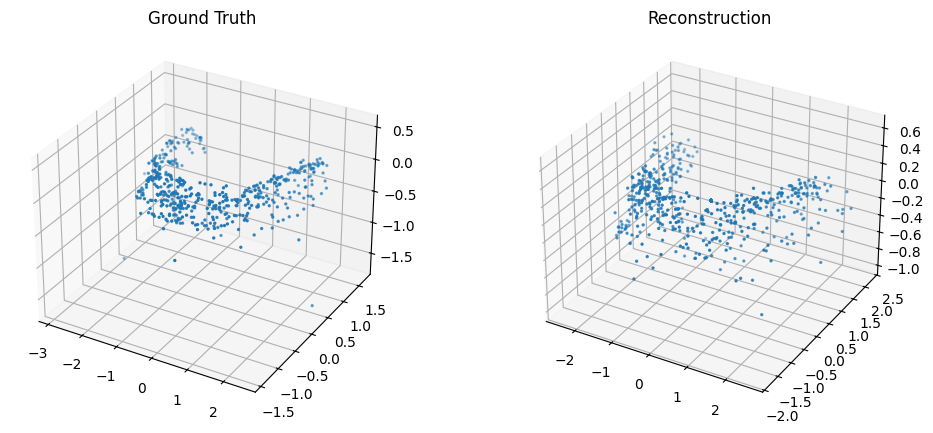

In [ ]:
from mpl_toolkits.mplot3d import Axes3D


snap = torch.load("/content/setvae/checkpoints/teeth_run_512_e10/recon_snapshots/epoch_0006.pt", map_location="cpu")

gt = snap["gt"][0]      # first sample
mask = snap["mask"][0]  # first sample
pred = snap["pred"][0] if snap["pred"] is not None else None

gt_valid = gt[~mask]

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(gt_valid[:, 0], gt_valid[:, 1], gt_valid[:, 2], s=2)
ax1.set_title("Ground Truth")

if pred is not None:
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(pred[:, 0], pred[:, 1], pred[:, 2], s=2)
    ax2.set_title("Reconstruction")

plt.show()

In [ ]:
%%writefile /content/setvae/extract_attention.py

def main():
    args = get_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    args.random_subsample = False
    args.random_offset = False

    model = SetVAE(args).to(device)

    ckpt = torch.load(args.resume_checkpoint, map_location=device)
    state_dict = ckpt["model"] if "model" in ckpt else ckpt
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    _, val_dataset, _, val_loader = get_datasets(args)

    save_dir = Path("/content/setvae/attention_outputs") / args.log_name
    save_dir.mkdir(parents=True, exist_ok=True)

    with torch.no_grad():
        for bidx, data in enumerate(val_loader):
            gt = data["set"].to(device)
            mask = data["set_mask"].to(device)

            out = model(gt, mask)

            enc_alphas, dec_alphas = out["alphas"]

            payload = {
                "gt": data["set"].cpu(),
                "mask": data["set_mask"].cpu(),
                "sid": data["sid"],
                "mid": data["mid"],
                "jaw": data["jaw"],
                "patient_id": data["patient_id"],
                "vertex_labels": data["vertex_labels"].cpu(),
                "vertex_instances": data["vertex_instances"].cpu(),
                "enc_alphas": [(a1.cpu(), a2.cpu()) for (a1, a2) in enc_alphas],
                "dec_alphas": [(a1.cpu(), a2.cpu()) for (a1, a2) in dec_alphas],
            }

            save_path = save_dir / f"batch_{bidx:04d}.pt"
            torch.save(payload, save_path)
            print(f"Saved {save_path}")

            if bidx >= 4:
                break


if __name__ == "__main__":
    main()

Writing /content/setvae/extract_attention.py


In [ ]:
%cd /content/setvae

!python extract_attention.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits/val.txt \
  --log_name teeth_run_512_e10 \
  --batch_size 4 \
  --num_workers 2 \
  --tr_max_sample_points 512 \
  --te_max_sample_points 512 \
  --resume_checkpoint /content/setvae/checkpoints/teeth_run_512_e10/checkpoint-latest.pt

/content/setvae
Device: cuda
[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=512, te_sample_size=512
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=512, te_sample_size=512
Saved /content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt
Saved /content/setvae/attention_outputs/teeth_run_512_e10/batch_0001.pt
Saved /content/setvae/attention_outputs/teeth_run_512_e10/batch_0002.pt
Saved /content/setvae/attention_outputs/teeth_run_512_e10/batch_0003.pt
Saved /content/setvae/attention_outputs/teeth_run_512_e10/batch_0004.pt


In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt", map_location="cpu")

print(att.keys())
print("gt:", att["gt"].shape)
print("mask:", att["mask"].shape)

print("\nEncoder levels:", len(att["enc_alphas"]))
for i, (a1, a2) in enumerate(att["enc_alphas"]):
    print(f"enc level {i}: alpha1={a1.shape}, alpha2={a2.shape}")

print("\nDecoder levels:", len(att["dec_alphas"]))
for i, (a1, a2) in enumerate(att["dec_alphas"]):
    print(f"dec level {i}: alpha1={a1.shape}, alpha2={a2.shape}")

dict_keys(['gt', 'mask', 'sid', 'mid', 'jaw', 'patient_id', 'vertex_labels', 'vertex_instances', 'enc_alphas', 'dec_alphas'])
gt: torch.Size([4, 512, 3])
mask: torch.Size([4, 512])

Encoder levels: 4
enc level 0: alpha1=torch.Size([4, 4, 512, 16]), alpha2=torch.Size([4, 4, 512, 16])
enc level 1: alpha1=torch.Size([4, 4, 512, 8]), alpha2=torch.Size([4, 4, 512, 8])
enc level 2: alpha1=torch.Size([4, 4, 512, 4]), alpha2=torch.Size([4, 4, 512, 4])
enc level 3: alpha1=torch.Size([4, 4, 512, 2]), alpha2=torch.Size([4, 4, 512, 2])

Decoder levels: 4
dec level 0: alpha1=torch.Size([4, 4, 2500, 2]), alpha2=torch.Size([4, 4, 2500, 2])
dec level 1: alpha1=torch.Size([4, 4, 2500, 4]), alpha2=torch.Size([4, 4, 2500, 4])
dec level 2: alpha1=torch.Size([4, 4, 2500, 8]), alpha2=torch.Size([4, 4, 2500, 8])
dec level 3: alpha1=torch.Size([4, 4, 2500, 16]), alpha2=torch.Size([4, 4, 2500, 16])


In [ ]:
file = "/content/setvae/figures/draw.py"

text = open(file).read()
text = text.replace("fig.gca(projection='3d')", "fig.add_subplot(111, projection='3d')")

open(file, "w").write(text)

print("draw.py patched successfully")

draw.py patched successfully


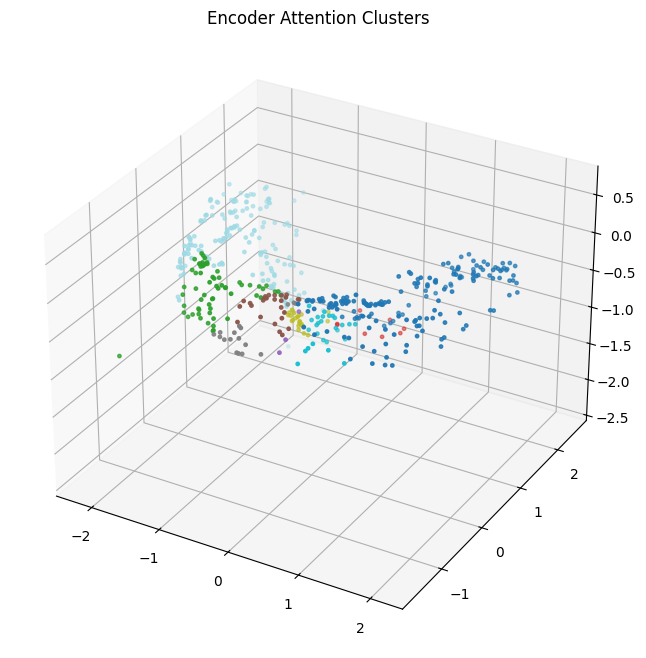

In [ ]:
points = att["gt"][0]   # [512,3]

cluster = alpha.argmax(dim=1)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    c=cluster,
    cmap="tab20",
    s=6
)

ax.set_title("Encoder Attention Clusters")
plt.show()

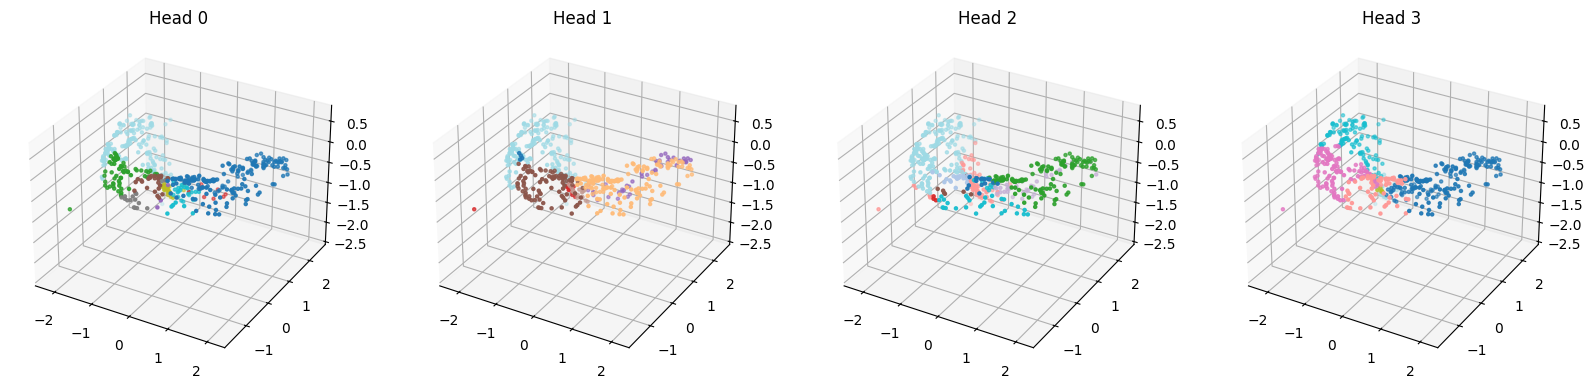

In [ ]:
fig = plt.figure(figsize=(20,5))

for h in range(alpha1.shape[0]):

    alpha = alpha1[h,0]
    cluster = alpha.argmax(dim=1)

    ax = fig.add_subplot(1,alpha1.shape[0],h+1, projection='3d')

    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        c=cluster,
        cmap="tab20",
        s=5
    )

    ax.set_title(f"Head {h}")

plt.show()

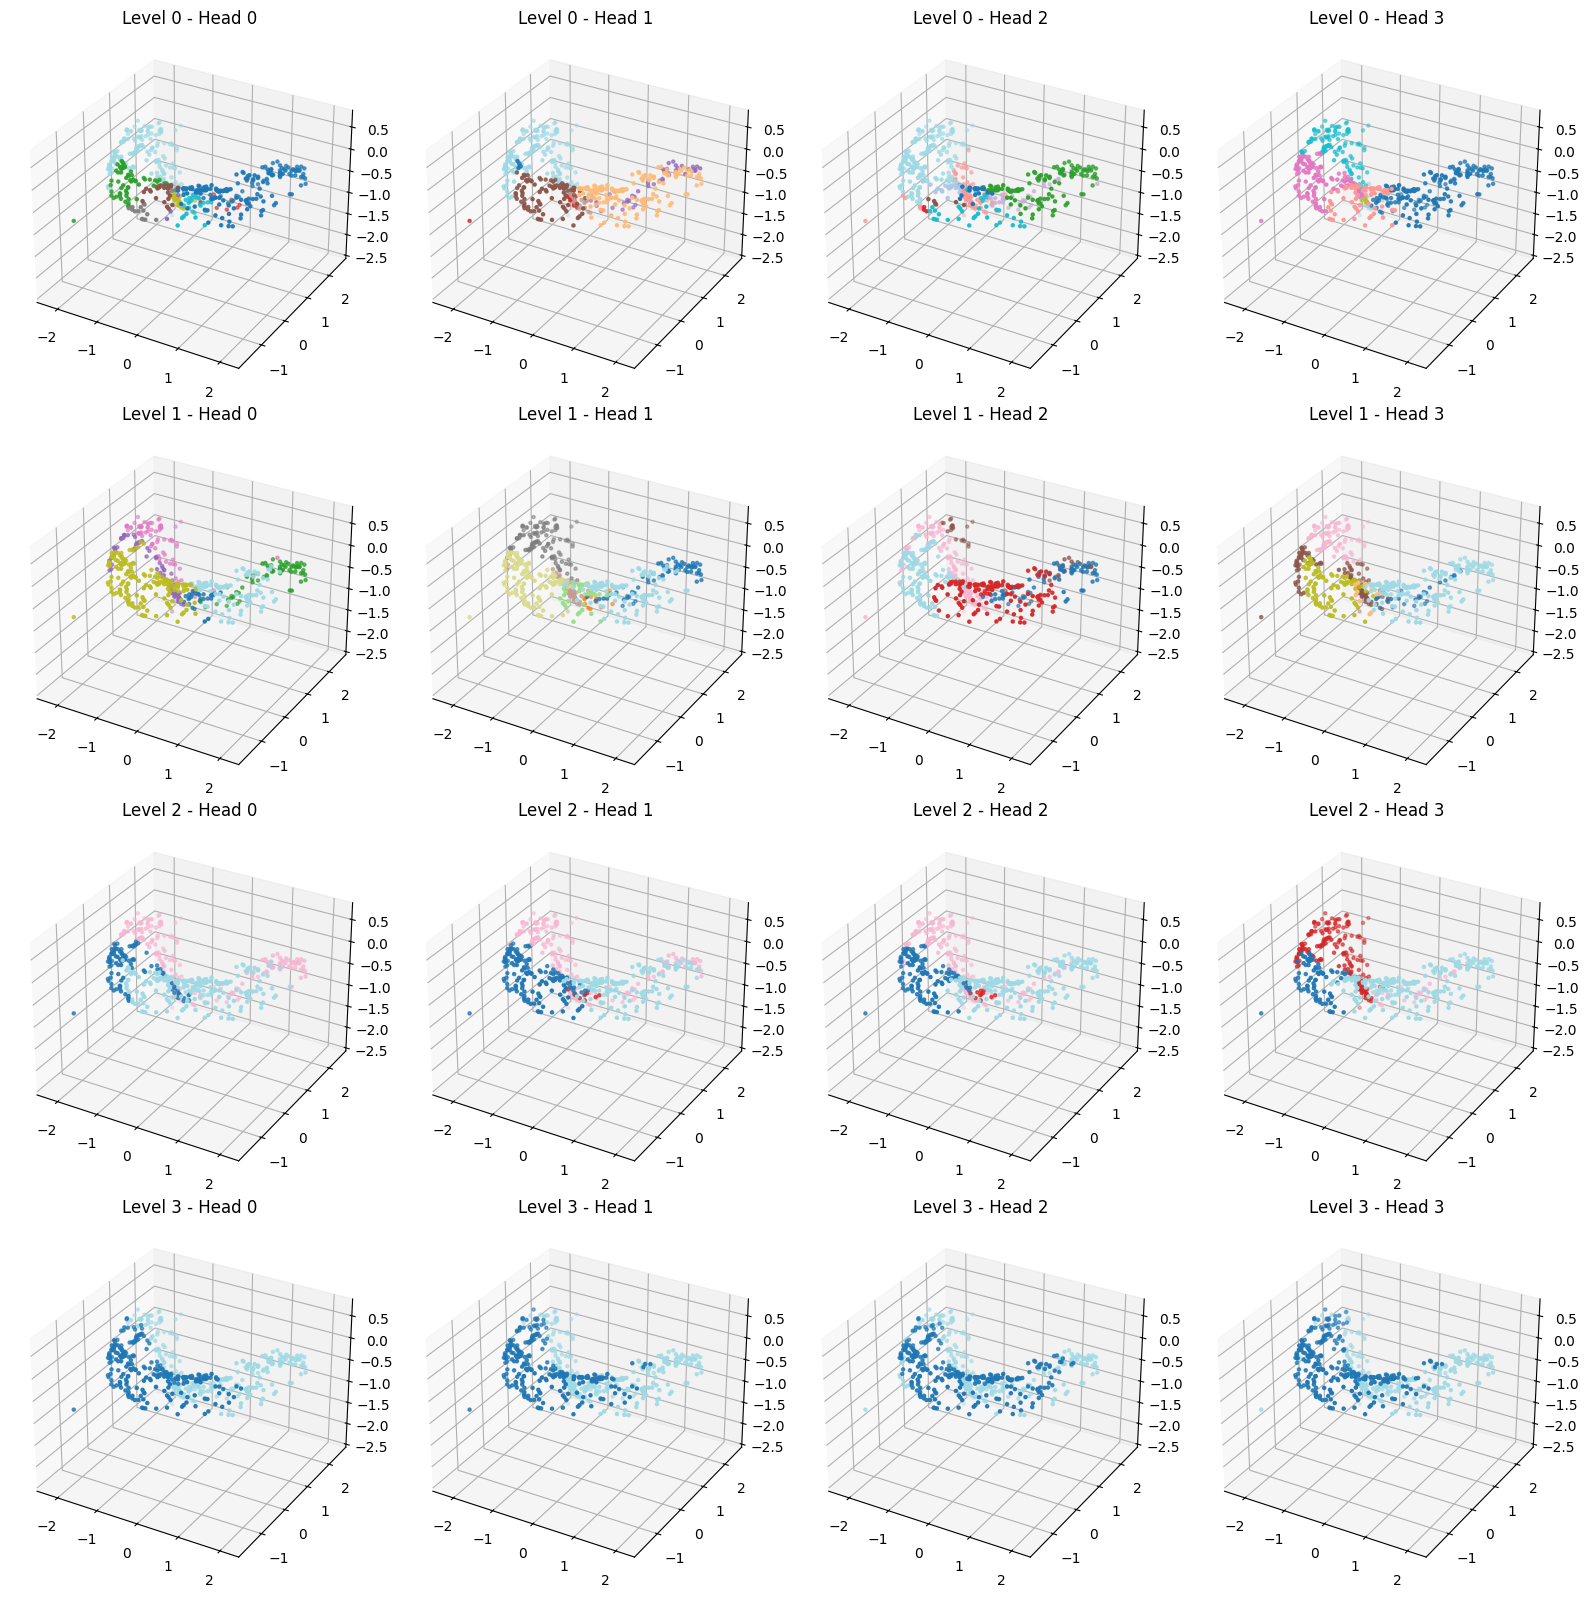

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt", map_location="cpu")
points = att["gt"][0]

n_levels = len(att["enc_alphas"])
n_heads = att["enc_alphas"][0][0].shape[0]

fig = plt.figure(figsize=(4 * n_heads, 4 * n_levels))

plot_idx = 1
for l in range(n_levels):
    alpha1, alpha2 = att["enc_alphas"][l]   # alpha1: [H, B, N, M]

    for h in range(n_heads):
        alpha = alpha1[h, 0]                # [N, M]
        cluster = alpha.argmax(dim=1)

        ax = fig.add_subplot(n_levels, n_heads, plot_idx, projection='3d')
        ax.scatter(
            points[:, 0],
            points[:, 1],
            points[:, 2],
            c=cluster,
            cmap="tab20",
            s=5
        )
        ax.set_title(f"Level {l} - Head {h}")
        plot_idx += 1

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

att = torch.load("/content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt", map_location="cpu")

alpha1, alpha2 = att["enc_alphas"][0]
instances = att["vertex_instances"][0]   # [512]
alpha = alpha1[0, 0]                     # head 0, sample 0, [512, 16]
cluster = alpha.argmax(dim=1)            # [512]

for c in range(cluster.max().item() + 1):
    mask = (cluster == c)
    inst_ids = instances[mask].tolist()
    if len(inst_ids) == 0:
        continue
    top = Counter(inst_ids).most_common(5)
    print(f"Cluster {c}: n_points={mask.sum().item()}, top_instances={top}")

Cluster 3: n_points=181, top_instances=[(0, 94), (1, 33), (11, 14), (10, 14), (12, 12)]
Cluster 5: n_points=65, top_instances=[(0, 32), (3, 16), (7, 15), (9, 2)]
Cluster 6: n_points=8, top_instances=[(0, 8)]
Cluster 7: n_points=3, top_instances=[(0, 2), (6, 1)]
Cluster 8: n_points=26, top_instances=[(6, 11), (0, 10), (7, 5)]
Cluster 10: n_points=17, top_instances=[(0, 14), (7, 3)]
Cluster 11: n_points=22, top_instances=[(0, 22)]
Cluster 12: n_points=27, top_instances=[(0, 25), (6, 2)]
Cluster 13: n_points=163, top_instances=[(0, 83), (2, 32), (4, 22), (5, 14), (9, 12)]


In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt", map_location="cpu")

alpha1, alpha2 = att["enc_alphas"][0]
instances = att["vertex_instances"][0]
alpha = alpha1[0, 0]  # head 0, sample 0
cluster = alpha.argmax(dim=1)

for c in range(cluster.max().item() + 1):
    mask = (cluster == c)
    n = mask.sum().item()
    if n == 0:
        continue

    vals = instances[mask].tolist()
    counts = Counter(vals)
    top_inst, top_count = counts.most_common(1)[0]
    purity = top_count / n

    entropy = 0.0
    for _, v in counts.items():
        p = v / n
        entropy -= p * math.log(p + 1e-12)

    print(f"Cluster {c:02d} | n={n:3d} | top_instance={top_inst} | purity={purity:.3f} | entropy={entropy:.3f} | counts={counts.most_common(5)}")

Cluster 03 | n=181 | top_instance=0 | purity=0.519 | entropy=1.465 | counts=[(0, 94), (1, 33), (11, 14), (10, 14), (12, 12)]
Cluster 05 | n= 65 | top_instance=0 | purity=0.492 | entropy=1.139 | counts=[(0, 32), (3, 16), (7, 15), (9, 2)]
Cluster 06 | n=  8 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 8)]
Cluster 07 | n=  3 | top_instance=0 | purity=0.667 | entropy=0.637 | counts=[(0, 2), (6, 1)]
Cluster 08 | n= 26 | top_instance=6 | purity=0.423 | entropy=1.048 | counts=[(6, 11), (0, 10), (7, 5)]
Cluster 10 | n= 17 | top_instance=0 | purity=0.824 | entropy=0.466 | counts=[(0, 14), (7, 3)]
Cluster 11 | n= 22 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 22)]
Cluster 12 | n= 27 | top_instance=0 | purity=0.926 | entropy=0.264 | counts=[(0, 25), (6, 2)]
Cluster 13 | n=163 | top_instance=0 | purity=0.509 | entropy=1.336 | counts=[(0, 83), (2, 32), (4, 22), (5, 14), (9, 12)]


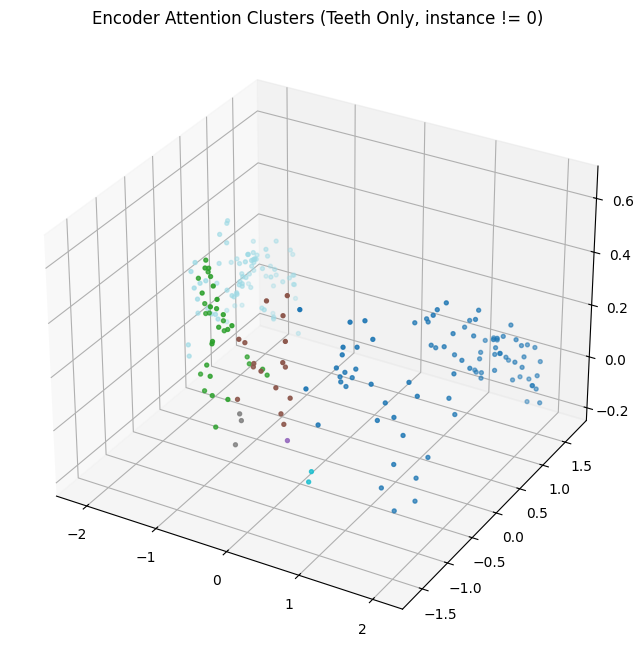

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_512_e10/batch_0000.pt", map_location="cpu")

points = att["gt"][0]
instances = att["vertex_instances"][0]

alpha1, alpha2 = att["enc_alphas"][0]
alpha = alpha1[0, 0]
cluster = alpha.argmax(dim=1)

tooth_mask = instances != 0

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    points[tooth_mask, 0],
    points[tooth_mask, 1],
    points[tooth_mask, 2],
    c=cluster[tooth_mask],
    cmap="tab20",
    s=8
)

ax.set_title("Encoder Attention Clusters (Teeth Only, instance != 0)")
plt.show()

# **Version 1**

In [ ]:
%%writefile /content/setvae/train_single.py


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val):
    ckpt = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_val": best_val,
    }
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    torch.save(ckpt, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"], strict=False)

    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])

    if scheduler is not None and "scheduler" in ckpt and ckpt["scheduler"] is not None:
        scheduler.load_state_dict(ckpt["scheduler"])

    start_epoch = ckpt.get("epoch", 0)
    best_val = ckpt.get("best_val", float("inf"))
    return model, optimizer, scheduler, start_epoch, best_val


def train_one_epoch(epoch, model, criterion, optimizer, loader, args, device, logger=None):
    model.train()

    loss_meter = AverageValueMeter()
    kl_meter = AverageValueMeter()
    l2_meter = AverageValueMeter()

    for i, data in enumerate(loader):
        gt = data["set"].to(device, non_blocking=True)
        mask = data["set_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        out = model(gt, mask)
        losses = criterion(out, gt, mask, args, epoch)

        loss = losses["loss"]
        kl = losses["kl"]
        l2 = losses["l2"]

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at epoch {epoch}, batch {i}: {loss.item()}")

        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), args.max_grad_norm)
        optimizer.step()

        bs = gt.size(0)
        loss_meter.update(loss.item(), bs)
        kl_meter.update(kl.item(), bs)
        l2_meter.update(l2.item(), bs)

        step = epoch * len(loader) + i
        if i % args.log_freq == 0:
            print(
                f"[Epoch {epoch:03d} | Batch {i:04d}/{len(loader):04d}] "
                f"Loss={loss.item():.4f} KL={kl.item():.4f} L2={l2.item():.4f} Grad={float(grad_norm):.4f}"
            )

            if logger is not None:
                logger.add_scalar("train_step/loss", loss.item(), step)
                logger.add_scalar("train_step/kl", kl.item(), step)
                logger.add_scalar("train_step/l2", l2.item(), step)
                logger.add_scalar("train_step/grad_norm", float(grad_norm), step)

    return {
        "loss": loss_meter.avg,
        "kl": kl_meter.avg,
        "l2": l2_meter.avg,
    }


@torch.no_grad()
def validate(model, criterion, loader, args, device):
    model.eval()

    loss_meter = AverageValueMeter()
    kl_meter = AverageValueMeter()
    l2_meter = AverageValueMeter()

    last_batch = None
    last_out = None

    for data in loader:
        gt = data["set"].to(device, non_blocking=True)
        mask = data["set_mask"].to(device, non_blocking=True)

        out = model(gt, mask)
        losses = criterion(out, gt, mask, args, epoch=0)

        loss = losses["loss"]
        kl = losses["kl"]
        l2 = losses["l2"]

        bs = gt.size(0)
        loss_meter.update(loss.item(), bs)
        kl_meter.update(kl.item(), bs)
        l2_meter.update(l2.item(), bs)

        last_batch = data
        last_out = out

    return {
        "loss": loss_meter.avg,
        "kl": kl_meter.avg,
        "l2": l2_meter.avg,
        "last_batch": last_batch,
        "last_out": last_out,
    }


@torch.no_grad()
def save_reconstruction_snapshot(save_dir, epoch, val_result):
    recon_dir = Path(save_dir) / "recon_snapshots"
    recon_dir.mkdir(parents=True, exist_ok=True)

    batch = val_result["last_batch"]
    out = val_result["last_out"]

    if batch is None or out is None:
        return

    pred = None
    for key in ["set", "recon_set", "reconstruction", "x_hat"]:
        if key in out:
            pred = out[key].detach().cpu()
            break

    payload = {
        "gt": batch["set"].detach().cpu(),
        "mask": batch["set_mask"].detach().cpu(),
        "pred": pred,
        "sid": batch.get("sid", None),
        "mid": batch.get("mid", None),
        "jaw": batch.get("jaw", None),
        "patient_id": batch.get("patient_id", None),
        "vertex_labels": batch.get("vertex_labels", None),
        "vertex_instances": batch.get("vertex_instances", None),
    }

    torch.save(payload, recon_dir / f"epoch_{epoch:04d}.pt")


def build_scheduler(args, optimizer):
    if args.scheduler == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)
    elif args.scheduler == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, args.epochs // 3), gamma=0.5)
    elif args.scheduler == "exponential":
        return torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=args.exp_decay)
    return None


def main():
    args = get_args()

    if args.log_name is None:
        args.log_name = "teeth_run"

    if args.seed is None:
        args.seed = random.randint(0, 1000000)

    set_random_seed(args.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cudnn.benchmark = torch.cuda.is_available()

    save_dir = Path("checkpoints") / args.log_name
    save_dir.mkdir(parents=True, exist_ok=True)

    log_dir = Path("runs") / args.log_name
    log_dir.mkdir(parents=True, exist_ok=True)

    print("Device:", device)
    print("Log name:", args.log_name)
    print("Seed:", args.seed)

    model = SetVAE(args).to(device)
    optimizer, criterion = model.make_optimizer(args)
    criterion = criterion.to(device)

    scheduler = build_scheduler(args, optimizer)

    train_dataset, val_dataset, train_loader, val_loader = get_datasets(args)

    logger = SummaryWriter(log_dir)

    train_dataset.save_statistics(save_dir)
    val_dataset.save_statistics(save_dir)

    start_epoch = 0
    best_val = float("inf")

    if args.resume_checkpoint is not None and Path(args.resume_checkpoint).exists():
        model, optimizer, scheduler, start_epoch, best_val = load_checkpoint(
            args.resume_checkpoint, model, optimizer, scheduler, device
        )
        print(f"Resumed from epoch {start_epoch}, best_val={best_val:.6f}")

    for epoch in range(start_epoch, args.epochs):
        train_res = train_one_epoch(epoch, model, criterion, optimizer, train_loader, args, device, logger)
        val_res = validate(model, criterion, val_loader, args, device)

        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss={train_res['loss']:.4f} train_kl={train_res['kl']:.4f} train_l2={train_res['l2']:.4f} | "
            f"val_loss={val_res['loss']:.4f} val_kl={val_res['kl']:.4f} val_l2={val_res['l2']:.4f}"
        )

        logger.add_scalar("train_epoch/loss", train_res["loss"], epoch)
        logger.add_scalar("train_epoch/kl", train_res["kl"], epoch)
        logger.add_scalar("train_epoch/l2", train_res["l2"], epoch)

        logger.add_scalar("val_epoch/loss", val_res["loss"], epoch)
        logger.add_scalar("val_epoch/kl", val_res["kl"], epoch)
        logger.add_scalar("val_epoch/l2", val_res["l2"], epoch)

        current_lr = optimizer.param_groups[0]["lr"]
        logger.add_scalar("train_epoch/lr", current_lr, epoch)

        save_reconstruction_snapshot(save_dir, epoch + 1, val_res)

        save_checkpoint(
            save_dir / "checkpoint-latest.pt",
            model, optimizer, scheduler, epoch + 1, best_val
        )

        if (epoch + 1) % args.save_freq == 0:
            save_checkpoint(
                save_dir / f"checkpoint-{epoch:04d}.pt",
                model, optimizer, scheduler, epoch + 1, best_val
            )

        if val_res["loss"] < best_val:
            best_val = val_res["loss"]
            save_checkpoint(
                save_dir / "checkpoint-best.pt",
                model, optimizer, scheduler, epoch + 1, best_val
            )
            print(f"New best checkpoint saved with val_loss={best_val:.6f}")

        if scheduler is not None:
            scheduler.step()

    logger.close()
    print("Training finished.")
    print(f"Best val loss: {best_val:.6f}")


if __name__ == "__main__":
    main()

Overwriting /content/setvae/train_single.py


In [ ]:
%cd /content/setvae

!python train_single.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits/val.txt \
  --log_name teeth_run_1024_e50 \
  --epochs 50 \
  --save_freq 5 \
  --log_freq 100 \
  --batch_size 4 \
  --num_workers 2 \
  --tr_max_sample_points 1024 \
  --te_max_sample_points 1024 \
  --matcher chamfer \
  --lr 1e-3 \
  --scheduler cosine

/content/setvae
2026-03-15 13:15:27.316921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773580527.339972   74635 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773580527.347682   74635 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773580527.368357   74635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773580527.368419   74635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773580527.368425   74635 computation_placer.cc:177] comput

In [ ]:
%%writefile /content/setvae/extract_attention.py


def main():
    args = get_args()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    args.random_subsample = False
    args.random_offset = False

    model = SetVAE(args).to(device)

    ckpt = torch.load(args.resume_checkpoint, map_location=device)
    state_dict = ckpt["model"] if "model" in ckpt else ckpt
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    _, _, _, val_loader = get_datasets(args)

    save_dir = Path("/content/setvae/attention_outputs") / args.log_name
    save_dir.mkdir(parents=True, exist_ok=True)

    with torch.no_grad():
        for bidx, data in enumerate(val_loader):
            gt = data["set"].to(device)
            mask = data["set_mask"].to(device)

            out = model(gt, mask)
            enc_alphas, dec_alphas = out["alphas"]

            payload = {
                "gt": data["set"].cpu(),
                "mask": data["set_mask"].cpu(),
                "sid": data["sid"],
                "mid": data["mid"],
                "jaw": data["jaw"],
                "patient_id": data["patient_id"],
                "vertex_labels": data["vertex_labels"].cpu(),
                "vertex_instances": data["vertex_instances"].cpu(),
                "enc_alphas": [(a1.cpu(), a2.cpu()) for (a1, a2) in enc_alphas],
                "dec_alphas": [(a1.cpu(), a2.cpu()) for (a1, a2) in dec_alphas],
            }

            save_path = save_dir / f"batch_{bidx:04d}.pt"
            torch.save(payload, save_path)
            print(f"Saved {save_path}")

            if bidx >= 9:
                break


if __name__ == "__main__":
    main()

Overwriting /content/setvae/extract_attention.py


In [ ]:
%cd /content/setvae

!python extract_attention.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits/val.txt \
  --log_name teeth_run_1024_e50 \
  --batch_size 4 \
  --num_workers 2 \
  --tr_max_sample_points 1024 \
  --te_max_sample_points 1024 \
  --resume_checkpoint /content/setvae/checkpoints/teeth_run_1024_e50/checkpoint-best.pt

/content/setvae
Device: cuda
[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=1024, te_sample_size=1024
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=1024, te_sample_size=1024
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0000.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0001.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0002.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0003.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0004.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0005.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0006.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0007.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0008.pt
Saved /content/setvae/attention_outputs/teeth_run_1024_e50/batch_0009.pt


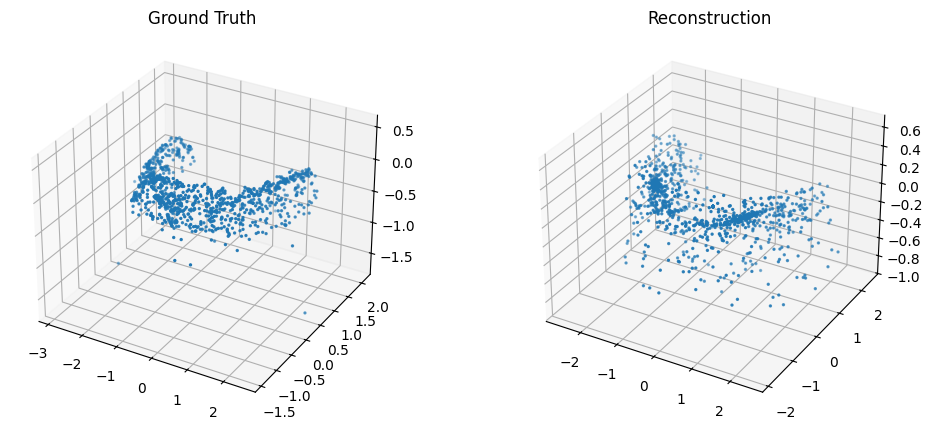

In [ ]:
snap = torch.load("/content/setvae/checkpoints/teeth_run_1024_e50/recon_snapshots/epoch_0050.pt", map_location="cpu")

gt = snap["gt"][0]
mask = snap["mask"][0]
pred = snap["pred"][0] if snap["pred"] is not None else None

gt_valid = gt[~mask]

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(gt_valid[:, 0], gt_valid[:, 1], gt_valid[:, 2], s=2)
ax1.set_title("Ground Truth")

if pred is not None:
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(pred[:, 0], pred[:, 1], pred[:, 2], s=2)
    ax2.set_title("Reconstruction")

plt.show()

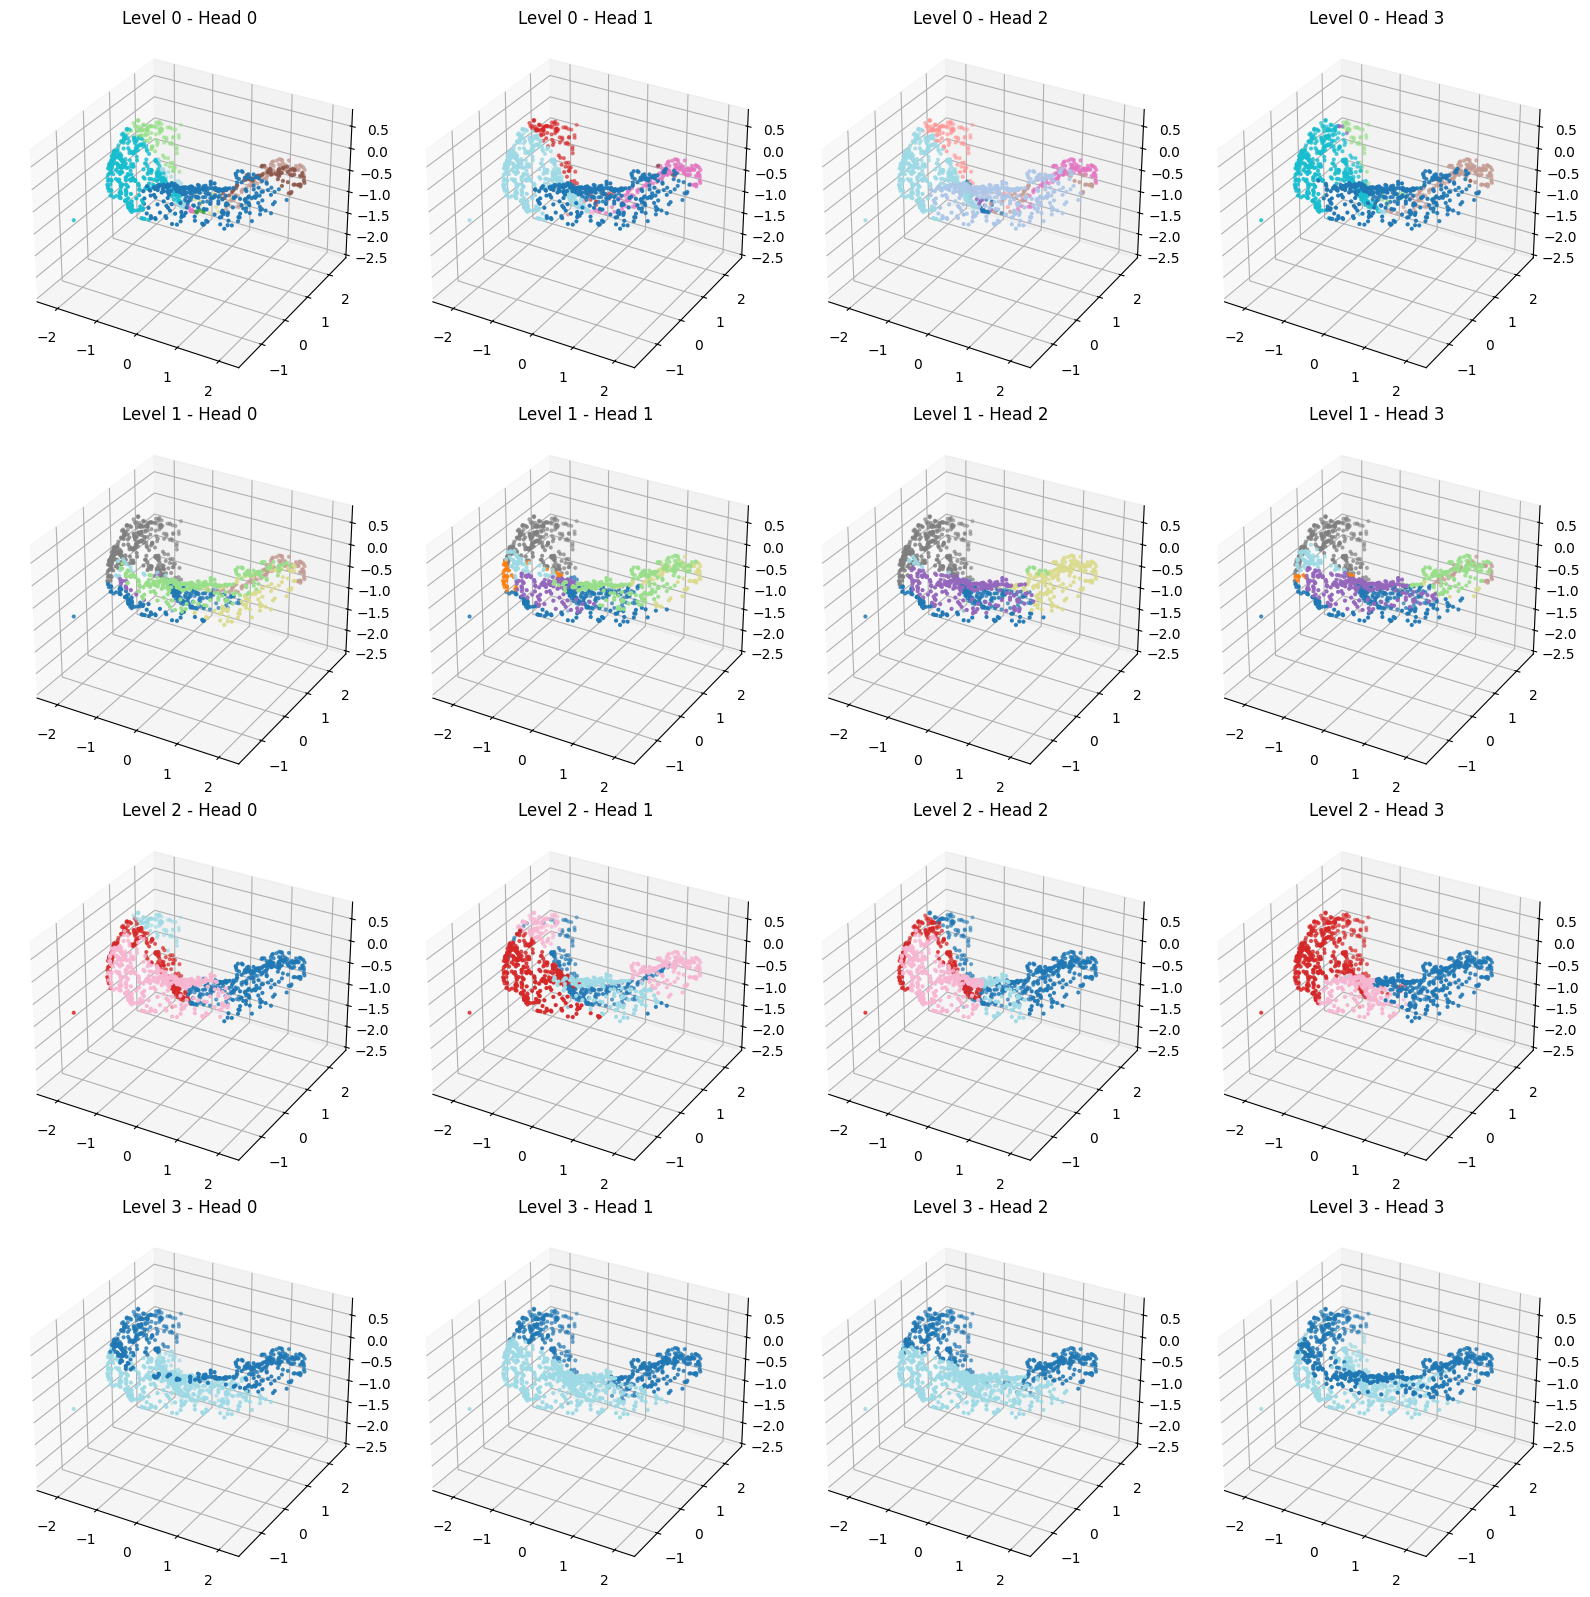

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_1024_e50/batch_0000.pt", map_location="cpu")
points = att["gt"][0]

n_levels = len(att["enc_alphas"])
n_heads = att["enc_alphas"][0][0].shape[0]

fig = plt.figure(figsize=(4 * n_heads, 4 * n_levels))
plot_idx = 1

for l in range(n_levels):
    alpha1, alpha2 = att["enc_alphas"][l]

    for h in range(n_heads):
        alpha = alpha1[h, 0]       # [N, M]
        cluster = alpha.argmax(dim=1)

        ax = fig.add_subplot(n_levels, n_heads, plot_idx, projection='3d')
        ax.scatter(
            points[:, 0],
            points[:, 1],
            points[:, 2],
            c=cluster,
            cmap="tab20",
            s=4
        )
        ax.set_title(f"Level {l} - Head {h}")
        plot_idx += 1

plt.tight_layout()
plt.show()

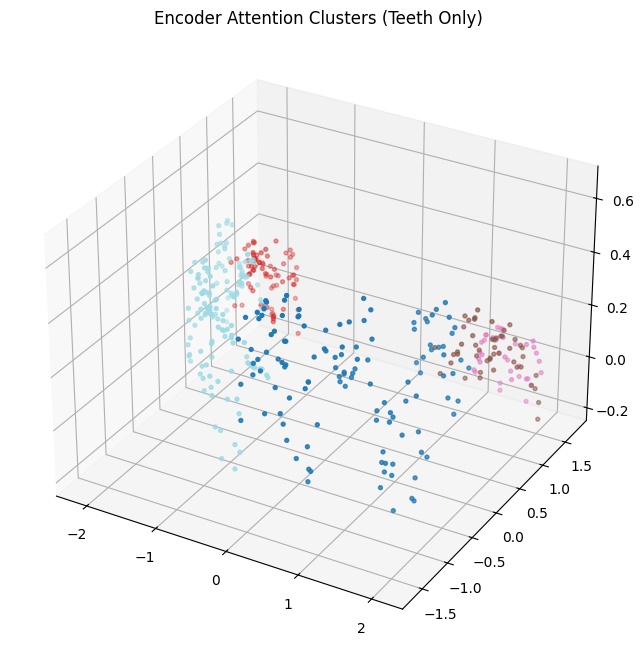

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_1024_e50/batch_0000.pt", map_location="cpu")

points = att["gt"][0]
instances = att["vertex_instances"][0]

alpha1, alpha2 = att["enc_alphas"][0]
alpha = alpha1[0, 0]   # head 0, sample 0
cluster = alpha.argmax(dim=1)

tooth_mask = instances != 0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    points[tooth_mask, 0],
    points[tooth_mask, 1],
    points[tooth_mask, 2],
    c=cluster[tooth_mask],
    cmap="tab20",
    s=8
)
ax.set_title("Encoder Attention Clusters (Teeth Only)")
plt.show()

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teeth_run_1024_e50/batch_0000.pt", map_location="cpu")

alpha1, alpha2 = att["enc_alphas"][0]
instances = att["vertex_instances"][0]

alpha = alpha1[0, 0]
cluster = alpha.argmax(dim=1)

for c in range(cluster.max().item() + 1):
    mask = (cluster == c)
    n = mask.sum().item()
    if n == 0:
        continue

    vals = instances[mask].tolist()
    counts = Counter(vals)
    top_inst, top_count = counts.most_common(1)[0]
    purity = top_count / n

    entropy = 0.0
    for _, v in counts.items():
        p = v / n
        entropy -= p * math.log(p + 1e-12)

    print(
        f"Cluster {c:02d} | n={n:4d} | "
        f"top_instance={top_inst} | purity={purity:.3f} | entropy={entropy:.3f} | "
        f"counts={counts.most_common(5)}"
    )

Cluster 01 | n= 315 | top_instance=0 | purity=0.613 | entropy=1.263 | counts=[(0, 193), (6, 40), (10, 25), (11, 25), (12, 24)]
Cluster 04 | n=   5 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 5)]
Cluster 05 | n= 113 | top_instance=2 | purity=0.513 | entropy=0.994 | counts=[(2, 58), (0, 38), (5, 17)]
Cluster 08 | n=  79 | top_instance=0 | purity=0.392 | entropy=1.178 | counts=[(0, 31), (8, 24), (1, 22), (11, 2)]
Cluster 09 | n=  84 | top_instance=0 | purity=0.571 | entropy=0.683 | counts=[(0, 48), (1, 36)]
Cluster 10 | n=   9 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 9)]
Cluster 13 | n=  18 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 18)]
Cluster 14 | n= 353 | top_instance=0 | purity=0.569 | entropy=1.394 | counts=[(0, 201), (7, 39), (4, 36), (9, 28), (3, 25)]
Cluster 15 | n=  48 | top_instance=0 | purity=1.000 | entropy=-0.000 | counts=[(0, 48)]


# **Version 2**

In [ ]:
RAW_ROOT = "/content/drive/MyDrive/teeth_setvae/raw_dataset"
OUT_ROOT = "/content/drive/MyDrive/teeth_setvae/processed_teethonly_2048"
os.makedirs(OUT_ROOT, exist_ok=True)

N_POINTS = 2048
SEED = 42
rng = np.random.default_rng(SEED)

def normalize_points(points):
    points = points.astype(np.float32)
    center = points.mean(axis=0, keepdims=True)
    points = points - center
    scale = np.linalg.norm(points, axis=1).max()
    if scale > 0:
        points = points / scale
    return points, center.astype(np.float32), np.float32(scale)

def sample_indices(n_vertices, n_points=2048):
    replace = n_vertices < n_points
    return rng.choice(n_vertices, size=n_points, replace=replace)

pairs = []
for jaw in ["lower", "upper"]:
    jaw_dir = os.path.join(RAW_ROOT, jaw)
    if not os.path.exists(jaw_dir):
        continue
    for patient_id in sorted(os.listdir(jaw_dir)):
        patient_dir = os.path.join(jaw_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        obj_path = os.path.join(patient_dir, f"{patient_id}_{jaw}.obj")
        json_path = os.path.join(patient_dir, f"{patient_id}_{jaw}.json")
        if os.path.exists(obj_path) and os.path.exists(json_path):
            pairs.append((patient_id, jaw, obj_path, json_path))

saved = 0
failed = []

for patient_id, jaw, obj_path, json_path in tqdm(pairs):
    try:
        mesh = trimesh.load(obj_path, process=False)
        vertices = np.asarray(mesh.vertices, dtype=np.float32)

        with open(json_path, "r") as f:
            ann = json.load(f)

        labels = np.asarray(ann["labels"], dtype=np.int32)
        instances = np.asarray(ann["instances"], dtype=np.int32)

        tooth_mask = instances != 0

        if tooth_mask.sum() < 50:
            failed.append((patient_id, jaw, "too_few_tooth_points"))
            continue

        vertices_tooth = vertices[tooth_mask]
        labels_tooth = labels[tooth_mask]
        instances_tooth = instances[tooth_mask]

        idx = sample_indices(len(vertices_tooth), N_POINTS)

        points_sampled = vertices_tooth[idx]
        labels_sampled = labels_tooth[idx]
        instances_sampled = instances_tooth[idx]

        points_norm, center, scale = normalize_points(points_sampled)

        out_path = os.path.join(OUT_ROOT, f"{patient_id}_{jaw}.npz")
        np.savez_compressed(
            out_path,
            points=points_norm.astype(np.float32),
            labels=labels_sampled.astype(np.int32),
            instances=instances_sampled.astype(np.int32),
            jaw=np.array(jaw),
            patient_id=np.array(patient_id),
            center=center,
            scale=np.array(scale, dtype=np.float32),
            original_num_vertices=np.array(len(vertices), dtype=np.int32),
            tooth_only=np.array(True),
        )
        saved += 1

    except Exception as e:
        failed.append((patient_id, jaw, str(e)))

print("Saved:", saved)
print("Failed:", len(failed))
print("First 10 failed:", failed[:10])

100%|██████████| 1800/1800 [1:49:44<00:00,  3.66s/it]

Saved: 1800
Failed: 0
First 10 failed: []


In [ ]:
processed_root = "/content/drive/MyDrive/teeth_setvae/processed_teethonly_2048"
split_root = "/content/drive/MyDrive/teeth_setvae/splits_teethonly_2048"
os.makedirs(split_root, exist_ok=True)

files = sorted(glob.glob(os.path.join(processed_root, "*.npz")))
random.seed(42)
random.shuffle(files)

n_train = int(0.9 * len(files))
train_files = files[:n_train]
val_files = files[n_train:]

with open(os.path.join(split_root, "train.txt"), "w") as f:
    f.write("\n".join(train_files))

with open(os.path.join(split_root, "val.txt"), "w") as f:
    f.write("\n".join(val_files))

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 1620
Val: 180


In [ ]:
%cd /content/setvae

!python train_single.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/val.txt \
  --log_name teethonly_v2_2048_e50 \
  --epochs 50 \
  --save_freq 5 \
  --log_freq 100 \
  --batch_size 2 \
  --num_workers 2 \
  --tr_max_sample_points 2048 \
  --te_max_sample_points 2048 \
  --matcher chamfer \
  --lr 1e-3 \
  --scheduler cosine \
  --isab_inds 32

/content/setvae
2026-03-15 10:55:05.340570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773572105.548639   35117 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773572105.606728   35117 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773572106.032761   35117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773572106.032812   35117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773572106.032819   35117 computation_placer.cc:177] comput

In [ ]:
%cd /content/setvae

!python train_single.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/val.txt \
  --log_name teethonly_v2_2048_e50 \
  --epochs 50 \
  --save_freq 5 \
  --log_freq 100 \
  --batch_size 2 \
  --num_workers 2 \
  --tr_max_sample_points 2048 \
  --te_max_sample_points 2048 \
  --matcher chamfer \
  --lr 1e-3 \
  --scheduler cosine \
  --isab_inds 32

/content/setvae
2026-03-15 11:48:32.733372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773575312.755424   51154 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773575312.762916   51154 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773575312.783303   51154 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773575312.783354   51154 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773575312.783359   51154 computation_placer.cc:177] comput

In [ ]:
!ls /content/setvae/checkpoints/teethonly_v2_2048_e50

checkpoint-0004.pt  checkpoint-0029.pt	checkpoint-latest.pt  val_set_idx.npy
checkpoint-0009.pt  checkpoint-0034.pt	recon_snapshots       val_set_mean.npy
checkpoint-0014.pt  checkpoint-0039.pt	train_set_idx.npy     val_set_std.npy
checkpoint-0019.pt  checkpoint-0044.pt	train_set_mean.npy
checkpoint-0024.pt  checkpoint-0049.pt	train_set_std.npy


In [ ]:
%cd /content/setvae

!python extract_attention.py \
  --dataset_type teeth3ds \
  --teeth_train_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/train.txt \
  --teeth_val_split /content/drive/MyDrive/teeth_setvae/splits_teethonly_2048/val.txt \
  --log_name teethonly_v2_2048_e50 \
  --batch_size 2 \
  --num_workers 2 \
  --tr_max_sample_points 2048 \
  --te_max_sample_points 2048 \
  --isab_inds 32 \
  --resume_checkpoint /content/setvae/checkpoints/teethonly_v2_2048_e50/checkpoint-0049.pt

/content/setvae
Device: cuda
[train] Total number of data: 1620
[train] Point count per sample: 2048
[train] tr_sample_size=2048, te_sample_size=2048
[val] Total number of data: 180
[val] Point count per sample: 2048
[val] tr_sample_size=2048, te_sample_size=2048
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0000.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0001.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0002.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0003.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0004.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0005.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0006.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0007.pt
Saved /content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0008.pt
Saved /content/setvae/attention_outputs/teethonly_v2

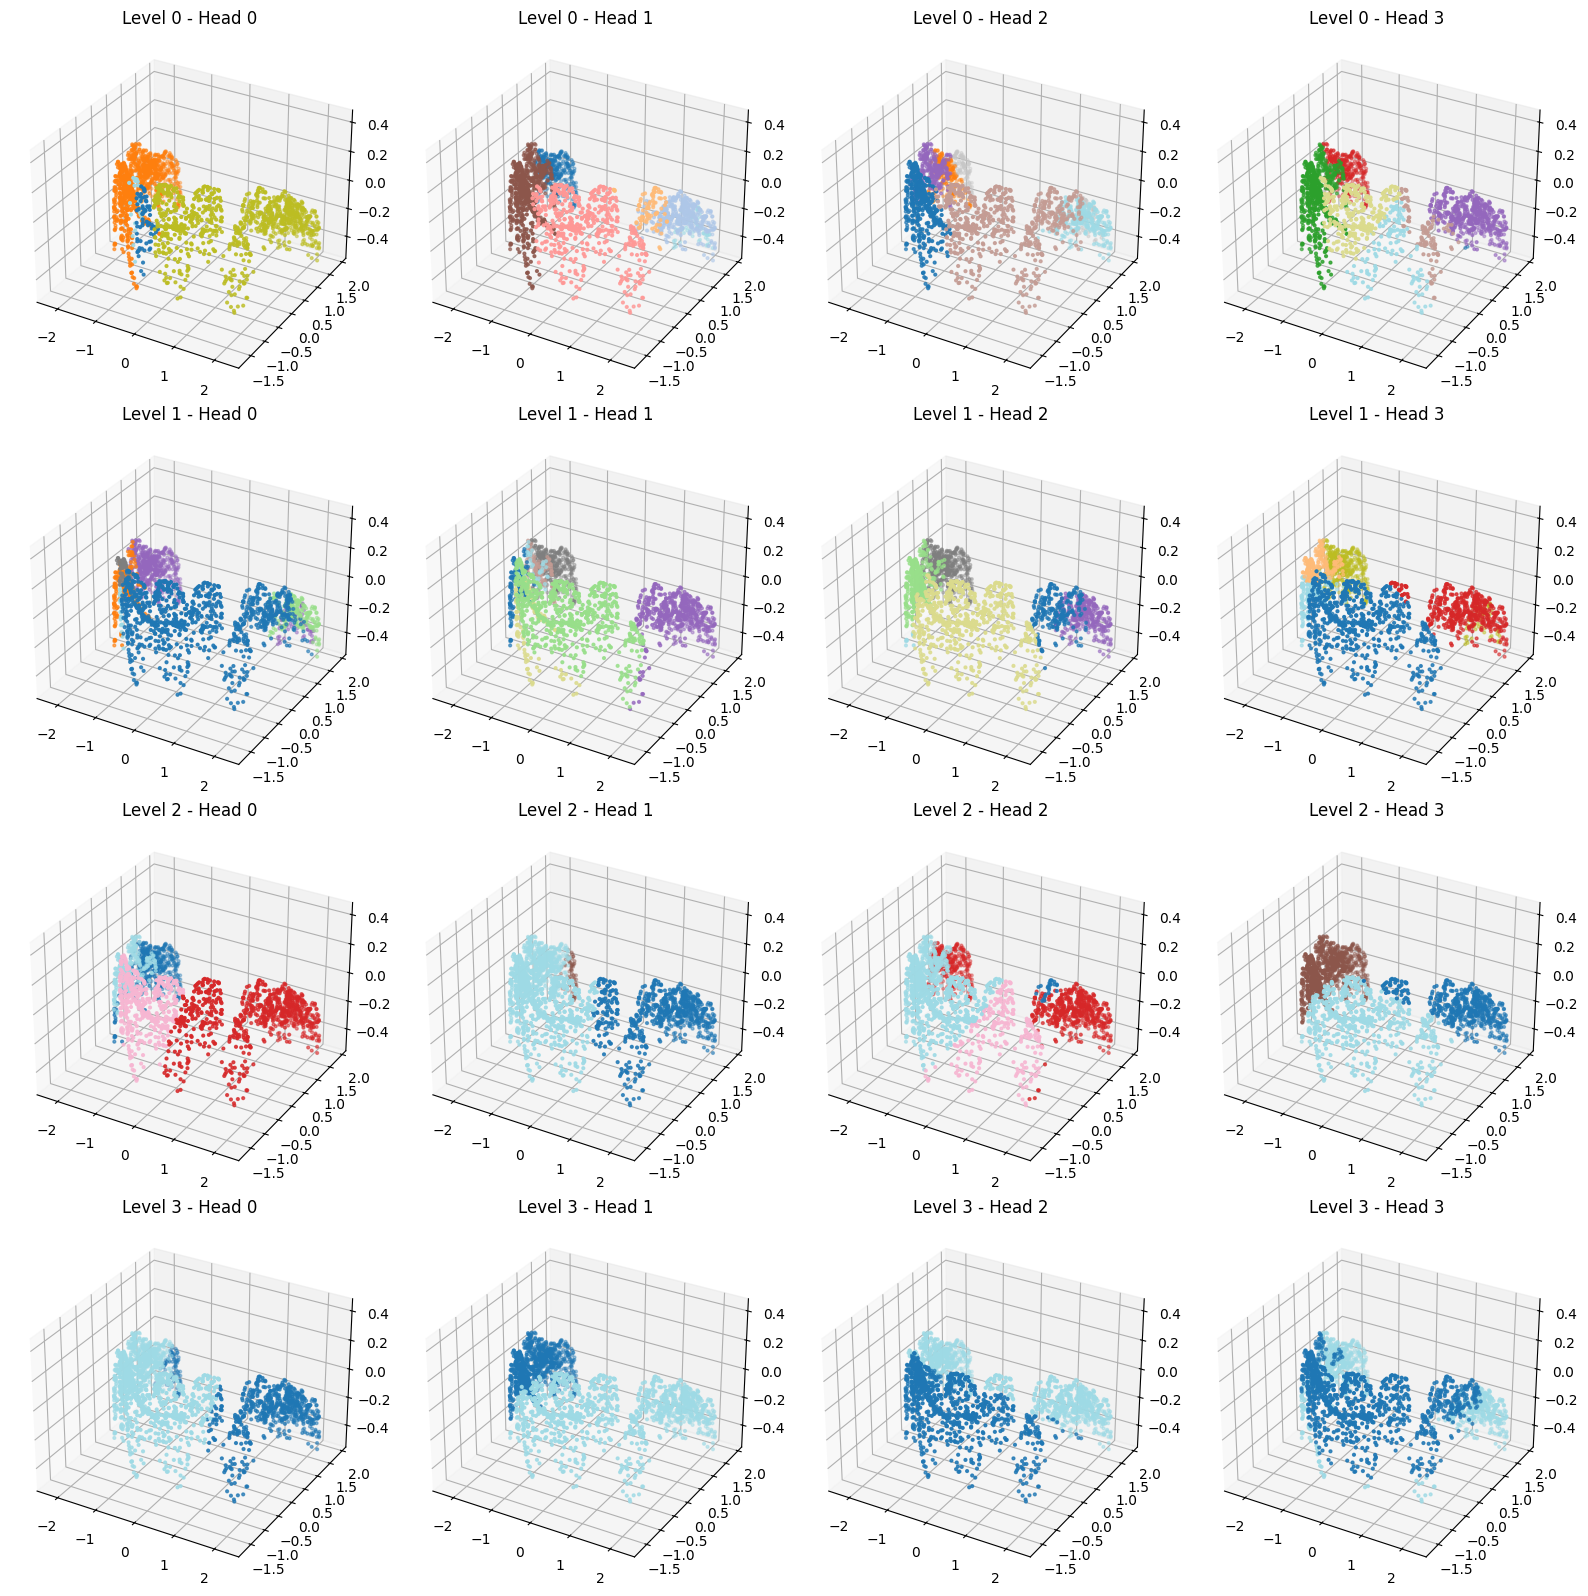

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0000.pt", map_location="cpu")
points = att["gt"][0]

n_levels = len(att["enc_alphas"])
n_heads = att["enc_alphas"][0][0].shape[0]

fig = plt.figure(figsize=(4 * n_heads, 4 * n_levels))
plot_idx = 1

for l in range(n_levels):
    alpha1, alpha2 = att["enc_alphas"][l]

    for h in range(n_heads):
        alpha = alpha1[h, 0]
        cluster = alpha.argmax(dim=1)

        ax = fig.add_subplot(n_levels, n_heads, plot_idx, projection='3d')
        ax.scatter(
            points[:, 0], points[:, 1], points[:, 2],
            c=cluster, cmap="tab20", s=4
        )
        ax.set_title(f"Level {l} - Head {h}")
        plot_idx += 1

plt.tight_layout()
plt.show()

In [ ]:
att = torch.load("/content/setvae/attention_outputs/teethonly_v2_2048_e50/batch_0000.pt", map_location="cpu")

alpha1, alpha2 = att["enc_alphas"][0]
instances = att["vertex_instances"][0]

alpha = alpha1[0, 0]
cluster = alpha.argmax(dim=1)

for c in range(cluster.max().item() + 1):
    mask = (cluster == c)
    n = mask.sum().item()
    if n == 0:
        continue

    vals = instances[mask].tolist()
    counts = Counter(vals)
    top_inst, top_count = counts.most_common(1)[0]
    purity = top_count / n

    entropy = 0.0
    for _, v in counts.items():
        p = v / n
        entropy -= p * math.log(p + 1e-12)

    print(
        f"Cluster {c:02d} | n={n:4d} | top_instance={top_inst} | "
        f"purity={purity:.3f} | entropy={entropy:.3f} | counts={counts.most_common(5)}"
    )

Cluster 03 | n=  74 | top_instance=7 | purity=0.986 | entropy=0.072 | counts=[(7, 73), (6, 1)]
Cluster 04 | n= 986 | top_instance=2 | purity=0.284 | entropy=1.735 | counts=[(2, 280), (5, 174), (4, 159), (3, 153), (9, 124)]
Cluster 11 | n= 963 | top_instance=1 | purity=0.261 | entropy=1.729 | counts=[(1, 251), (6, 213), (8, 159), (11, 131), (10, 129)]
Cluster 13 | n=  25 | top_instance=7 | purity=1.000 | entropy=-0.000 | counts=[(7, 25)]


# **COMPARE**

In [ ]:
RUNS = {
    "V1_fulljaw_1024": "/content/setvae/attention_outputs/teeth_run_1024_e50",
    "V2_teethonly_2048": "/content/setvae/attention_outputs/teethonly_v2_2048_e50",
}

def load_attention_batch(run_dir, batch_idx=0):
    path = os.path.join(run_dir, f"batch_{batch_idx:04d}.pt")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return torch.load(path, map_location="cpu")

def get_cluster_assignment(att, level=0, head=0, sample_idx=0, alpha_choice="alpha1"):
    alpha1, alpha2 = att["enc_alphas"][level]
    alpha = alpha1 if alpha_choice == "alpha1" else alpha2
    # alpha shape: [H, B, N, M]
    cluster = alpha[head, sample_idx].argmax(dim=1)
    return cluster

def cluster_metrics(cluster, instances, ignore_zero=False):
    cluster = cluster.cpu().numpy()
    instances = instances.cpu().numpy()

    if ignore_zero:
        mask = instances != 0
        cluster = cluster[mask]
        instances = instances[mask]

    if len(instances) == 0:
        return {
            "mean_purity": np.nan,
            "weighted_purity": np.nan,
            "mean_entropy": np.nan,
            "nmi": np.nan,
            "ari": np.nan,
            "n_points": 0,
            "n_clusters_used": 0,
        }

    unique_clusters = np.unique(cluster)

    purities = []
    entropies = []
    weights = []

    for c in unique_clusters:
        mask = cluster == c
        vals = instances[mask]
        n = len(vals)
        if n == 0:
            continue

        counts = Counter(vals.tolist())
        top_count = counts.most_common(1)[0][1]
        purity = top_count / n

        entropy = 0.0
        for v in counts.values():
            p = v / n
            entropy -= p * math.log(p + 1e-12)

        purities.append(purity)
        entropies.append(entropy)
        weights.append(n)

    purities = np.array(purities, dtype=float)
    entropies = np.array(entropies, dtype=float)
    weights = np.array(weights, dtype=float)

    return {
        "mean_purity": float(np.mean(purities)) if len(purities) else np.nan,
        "weighted_purity": float(np.sum(purities * weights) / np.sum(weights)) if len(purities) else np.nan,
        "mean_entropy": float(np.mean(entropies)) if len(entropies) else np.nan,
        "nmi": float(normalized_mutual_info_score(instances, cluster)),
        "ari": float(adjusted_rand_score(instances, cluster)),
        "n_points": int(len(instances)),
        "n_clusters_used": int(len(unique_clusters)),
    }

def print_cluster_details(att, level=0, head=0, sample_idx=0, ignore_zero=False):
    cluster = get_cluster_assignment(att, level=level, head=head, sample_idx=sample_idx)
    instances = att["vertex_instances"][sample_idx]

    if ignore_zero:
        valid = instances != 0
        cluster = cluster[valid]
        instances = instances[valid]

    for c in range(int(cluster.max().item()) + 1):
        mask = cluster == c
        n = int(mask.sum().item())
        if n == 0:
            continue

        vals = instances[mask].tolist()
        counts = Counter(vals)
        top_inst, top_count = counts.most_common(1)[0]
        purity = top_count / n

        entropy = 0.0
        for _, v in counts.items():
            p = v / n
            entropy -= p * math.log(p + 1e-12)

        print(
            f"Cluster {c:02d} | n={n:4d} | top_instance={top_inst} | "
            f"purity={purity:.3f} | entropy={entropy:.3f} | counts={counts.most_common(5)}"
        )

In [ ]:
def plot_v1_v2_side_by_side(
    batch_idx=0,
    sample_idx=0,
    level=1,
    head=3,
    ignore_zero_for_v1=True,
    figsize=(14, 6),
    point_size=6
):
    att_v1 = load_attention_batch(RUNS["V1_fulljaw_1024"], batch_idx=batch_idx)
    att_v2 = load_attention_batch(RUNS["V2_teethonly_2048"], batch_idx=batch_idx)

    pts_v1 = att_v1["gt"][sample_idx]
    inst_v1 = att_v1["vertex_instances"][sample_idx]
    cl_v1 = get_cluster_assignment(att_v1, level=level, head=head, sample_idx=sample_idx)

    pts_v2 = att_v2["gt"][sample_idx]
    inst_v2 = att_v2["vertex_instances"][sample_idx]
    cl_v2 = get_cluster_assignment(att_v2, level=level, head=head, sample_idx=sample_idx)

    if ignore_zero_for_v1:
        mask_v1 = inst_v1 != 0
        pts_v1 = pts_v1[mask_v1]
        cl_v1 = cl_v1[mask_v1]

    fig = plt.figure(figsize=figsize)

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(
        pts_v1[:, 0], pts_v1[:, 1], pts_v1[:, 2],
        c=cl_v1, cmap="tab20", s=point_size
    )
    ax1.set_title(f"V1 Full Jaw (filtered teeth only)\nLevel {level} - Head {head}")

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(
        pts_v2[:, 0], pts_v2[:, 1], pts_v2[:, 2],
        c=cl_v2, cmap="tab20", s=point_size
    )
    ax2.set_title(f"V2 Teeth Only\nLevel {level} - Head {head}")

    plt.tight_layout()
    plt.show()

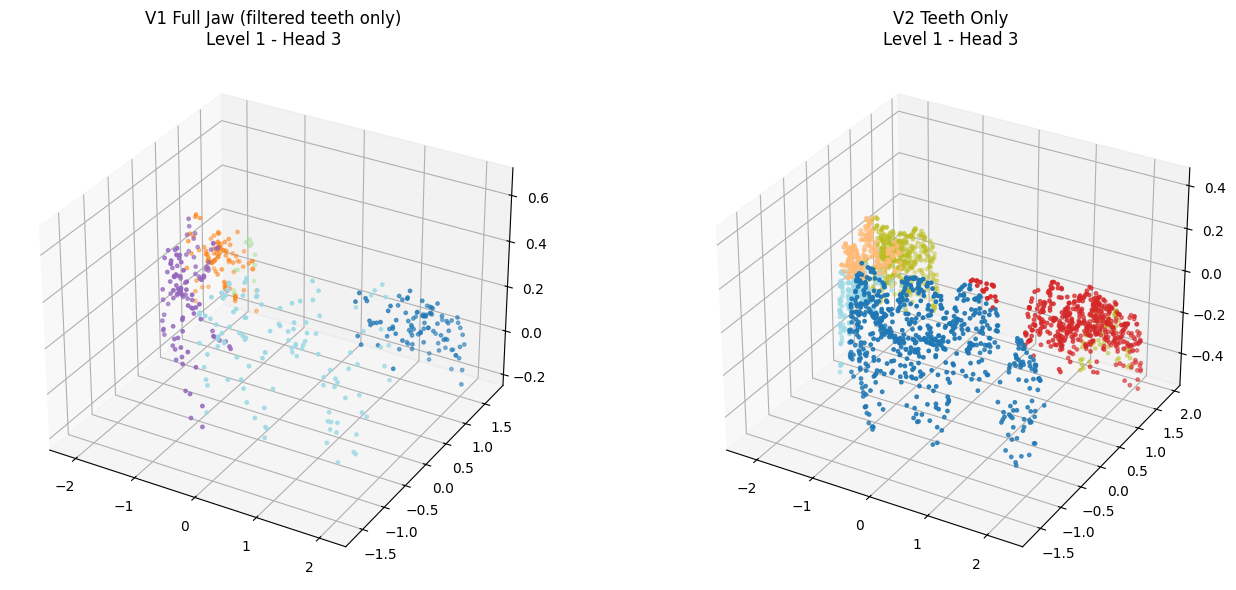

In [ ]:
plot_v1_v2_side_by_side(batch_idx=0, sample_idx=0, level=1, head=3)

In [ ]:
def compare_one_setting(batch_idx=0, sample_idx=0, level=1, head=3):
    att_v1 = load_attention_batch(RUNS["V1_fulljaw_1024"], batch_idx=batch_idx)
    att_v2 = load_attention_batch(RUNS["V2_teethonly_2048"], batch_idx=batch_idx)

    cl_v1 = get_cluster_assignment(att_v1, level=level, head=head, sample_idx=sample_idx)
    inst_v1 = att_v1["vertex_instances"][sample_idx]

    cl_v2 = get_cluster_assignment(att_v2, level=level, head=head, sample_idx=sample_idx)
    inst_v2 = att_v2["vertex_instances"][sample_idx]

    m_v1 = cluster_metrics(cl_v1, inst_v1, ignore_zero=True)   # fair comparison on teeth
    m_v2 = cluster_metrics(cl_v2, inst_v2, ignore_zero=False)  # already teeth-only

    print(f"Comparison for Level {level}, Head {head}, Sample {sample_idx}, Batch {batch_idx}")
    print("-" * 80)
    print("V1 Full Jaw (teeth points only for evaluation)")
    for k, v in m_v1.items():
        print(f"  {k}: {v}")
    print()
    print("V2 Teeth Only")
    for k, v in m_v2.items():
        print(f"  {k}: {v}")

In [ ]:
compare_one_setting(batch_idx=0, sample_idx=0, level=1, head=3)

Comparison for Level 1, Head 3, Sample 0, Batch 0
--------------------------------------------------------------------------------
V1 Full Jaw (teeth points only for evaluation)
  mean_purity: 0.5519226750261232
  weighted_purity: 0.44341801385681295
  mean_entropy: 0.9330991206873943
  nmi: 0.648912686632167
  ari: 0.3861101458504658
  n_points: 433
  n_clusters_used: 5

V2 Teeth Only
  mean_purity: 0.4539024621238418
  weighted_purity: 0.43017578125
  mean_entropy: 1.2462562413345732
  nmi: 0.5914388343970554
  ari: 0.3631791091223533
  n_points: 2048
  n_clusters_used: 5


In [ ]:
def search_best_heads_levels(batch_idx=0, sample_idx=0):
    att_v1 = load_attention_batch(RUNS["V1_fulljaw_1024"], batch_idx=batch_idx)
    att_v2 = load_attention_batch(RUNS["V2_teethonly_2048"], batch_idx=batch_idx)

    n_levels_v1 = len(att_v1["enc_alphas"])
    n_heads_v1 = att_v1["enc_alphas"][0][0].shape[0]

    n_levels_v2 = len(att_v2["enc_alphas"])
    n_heads_v2 = att_v2["enc_alphas"][0][0].shape[0]

    rows = []

    # V1
    for level in range(n_levels_v1):
        for head in range(n_heads_v1):
            cl = get_cluster_assignment(att_v1, level=level, head=head, sample_idx=sample_idx)
            inst = att_v1["vertex_instances"][sample_idx]
            metrics = cluster_metrics(cl, inst, ignore_zero=True)
            rows.append({
                "run": "V1_fulljaw_1024",
                "level": level,
                "head": head,
                **metrics
            })

    # V2
    for level in range(n_levels_v2):
        for head in range(n_heads_v2):
            cl = get_cluster_assignment(att_v2, level=level, head=head, sample_idx=sample_idx)
            inst = att_v2["vertex_instances"][sample_idx]
            metrics = cluster_metrics(cl, inst, ignore_zero=False)
            rows.append({
                "run": "V2_teethonly_2048",
                "level": level,
                "head": head,
                **metrics
            })

    import pandas as pd
    df = pd.DataFrame(rows)

    print("Top by weighted purity")
    display(df.sort_values("weighted_purity", ascending=False).head(10))

    print("Top by NMI")
    display(df.sort_values("nmi", ascending=False).head(10))

    print("Top by ARI")
    display(df.sort_values("ari", ascending=False).head(10))

    return df

In [ ]:
df_compare = search_best_heads_levels(batch_idx=0, sample_idx=0)

Top by weighted purity


,run,level,head,mean_purity,weighted_purity,mean_entropy,nmi,ari,n_points,n_clusters_used
21,V2_teethonly_2048,1,1,0.622907,0.519531,0.839476,0.677459,0.426442,2048,7
1,V1_fulljaw_1024,0,1,0.638676,0.498845,0.790457,0.658511,0.366781,433,6
3,V1_fulljaw_1024,0,3,0.737427,0.498845,0.655979,0.645399,0.345269,433,6
18,V2_teethonly_2048,0,2,0.551772,0.495605,0.914016,0.665342,0.402286,2048,6
22,V2_teethonly_2048,1,2,0.522724,0.489258,0.960809,0.676596,0.443497,2048,6
19,V2_teethonly_2048,0,3,0.586569,0.481934,0.883420,0.654956,0.416863,2048,8
17,V2_teethonly_2048,0,1,0.648585,0.475098,0.763558,0.653544,0.379149,2048,6
5,V1_fulljaw_1024,1,1,0.576961,0.468822,0.903729,0.676412,0.426995,433,5
4,V1_fulljaw_1024,1,0,0.466973,0.468822,1.135383,0.683631,0.436366,433,4
6,V1_fulljaw_1024,1,2,0.468113,0.464203,1.170217,0.657274,0.415918,433,4


Top by NMI


,run,level,head,mean_purity,weighted_purity,mean_entropy,nmi,ari,n_points,n_clusters_used
4,V1_fulljaw_1024,1,0,0.466973,0.468822,1.135383,0.683631,0.436366,433,4
21,V2_teethonly_2048,1,1,0.622907,0.519531,0.839476,0.677459,0.426442,2048,7
22,V2_teethonly_2048,1,2,0.522724,0.489258,0.960809,0.676596,0.443497,2048,6
5,V1_fulljaw_1024,1,1,0.576961,0.468822,0.903729,0.676412,0.426995,433,5
18,V2_teethonly_2048,0,2,0.551772,0.495605,0.914016,0.665342,0.402286,2048,6
1,V1_fulljaw_1024,0,1,0.638676,0.498845,0.790457,0.658511,0.366781,433,6
6,V1_fulljaw_1024,1,2,0.468113,0.464203,1.170217,0.657274,0.415918,433,4
19,V2_teethonly_2048,0,3,0.586569,0.481934,0.883420,0.654956,0.416863,2048,8
17,V2_teethonly_2048,0,1,0.648585,0.475098,0.763558,0.653544,0.379149,2048,6
7,V1_fulljaw_1024,1,3,0.551923,0.443418,0.933099,0.648913,0.386110,433,5


Top by ARI


,run,level,head,mean_purity,weighted_purity,mean_entropy,nmi,ari,n_points,n_clusters_used
22,V2_teethonly_2048,1,2,0.522724,0.489258,0.960809,0.676596,0.443497,2048,6
4,V1_fulljaw_1024,1,0,0.466973,0.468822,1.135383,0.683631,0.436366,433,4
5,V1_fulljaw_1024,1,1,0.576961,0.468822,0.903729,0.676412,0.426995,433,5
21,V2_teethonly_2048,1,1,0.622907,0.519531,0.839476,0.677459,0.426442,2048,7
19,V2_teethonly_2048,0,3,0.586569,0.481934,0.883420,0.654956,0.416863,2048,8
6,V1_fulljaw_1024,1,2,0.468113,0.464203,1.170217,0.657274,0.415918,433,4
18,V2_teethonly_2048,0,2,0.551772,0.495605,0.914016,0.665342,0.402286,2048,6
7,V1_fulljaw_1024,1,3,0.551923,0.443418,0.933099,0.648913,0.386110,433,5
17,V2_teethonly_2048,0,1,0.648585,0.475098,0.763558,0.653544,0.379149,2048,6
1,V1_fulljaw_1024,0,1,0.638676,0.498845,0.790457,0.658511,0.366781,433,6


In [ ]:
def plot_best_from_df(df, metric="nmi", batch_idx=0, sample_idx=0):
    best_v1 = df[df["run"] == "V1_fulljaw_1024"].sort_values(metric, ascending=False).iloc[0]
    best_v2 = df[df["run"] == "V2_teethonly_2048"].sort_values(metric, ascending=False).iloc[0]

    print("Best V1:", best_v1[["level", "head", metric]].to_dict())
    print("Best V2:", best_v2[["level", "head", metric]].to_dict())

    plot_v1_v2_side_by_side(
        batch_idx=batch_idx,
        sample_idx=sample_idx,
        level=int(best_v2["level"]),   # temporary, same level/head for both not ideal
        head=int(best_v2["head"])
    )

    return best_v1, best_v2

In [ ]:
def plot_two_custom_settings(
    batch_idx=0,
    sample_idx=0,
    v1_level=1, v1_head=3,
    v2_level=1, v2_head=3,
    figsize=(14,6),
    point_size=6
):
    att_v1 = load_attention_batch(RUNS["V1_fulljaw_1024"], batch_idx=batch_idx)
    att_v2 = load_attention_batch(RUNS["V2_teethonly_2048"], batch_idx=batch_idx)

    pts_v1 = att_v1["gt"][sample_idx]
    inst_v1 = att_v1["vertex_instances"][sample_idx]
    cl_v1 = get_cluster_assignment(att_v1, level=v1_level, head=v1_head, sample_idx=sample_idx)
    mask_v1 = inst_v1 != 0
    pts_v1 = pts_v1[mask_v1]
    cl_v1 = cl_v1[mask_v1]

    pts_v2 = att_v2["gt"][sample_idx]
    cl_v2 = get_cluster_assignment(att_v2, level=v2_level, head=v2_head, sample_idx=sample_idx)

    fig = plt.figure(figsize=figsize)

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(pts_v1[:,0], pts_v1[:,1], pts_v1[:,2], c=cl_v1, cmap="tab20", s=point_size)
    ax1.set_title(f"V1 best\nLevel {v1_level} - Head {v1_head}")

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(pts_v2[:,0], pts_v2[:,1], pts_v2[:,2], c=cl_v2, cmap="tab20", s=point_size)
    ax2.set_title(f"V2 best\nLevel {v2_level} - Head {v2_head}")

    plt.tight_layout()
    plt.show()